# 1\.4\.1 Explore Temporal and Spatial Mobility Patterns

This notebook explores a small set of high\-value temporal and spatial mobility questions using the processed 1\.3\.1 tables\. We are not repeating broad QA or trying to exhaust every possible visualization\. Instead, we are focusing on a few questions that can generate real insight for later clustering, anomaly detection, supervised learning, and forecasting, while also surfacing strong visuals we may want to reuse in the app later\. The notebook should stay tightly scoped, use the existing temporal ordering fields, and prioritize clear comparisons over volume of charts\.

Before we define the notebook questions, let's load the shared analysis tools and set the small number of paths, dates, ordering rules, and metric choices used throughout the notebook\. These controls keep later sections consistent without turning the setup into its own chapter\.

In [1]:
from pathlib import Path

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.colors import LinearSegmentedColormap
from shapely import wkb

from project_branding import (
    BRAND_COLORS,
    BRAND_COLOR_SEQUENCE,
    BRAND_DIVERGING_SEQUENCE,
    BRAND_MAP_COLORS,
)

In [2]:
# ---------------------------------------------------------------------
# 1.4.1 Controls, paths, and shared analytical definitions
# ---------------------------------------------------------------------

PIPELINE_DATA_DIR = Path("pipeline_data")
MERGED_FINAL_DIR = PIPELINE_DATA_DIR / "1.3.1.final_tables"
EDA_OUTPUT_DIR = PIPELINE_DATA_DIR / "1.4.1.outputs"

ANALYSIS_PANEL_PATH = MERGED_FINAL_DIR / "analysis_ready_mobility_panel.parquet"
AUDIT_PANEL_PATH = MERGED_FINAL_DIR / "audit_only_mobility_panel.parquet"
TAXI_ZONE_SPATIAL_CONTEXT_PATH = MERGED_FINAL_DIR / "nyc_taxi_zones_harmonized.parquet"
TAXI_ZONE_CONNECTIVITY_PATH = MERGED_FINAL_DIR / "taxi_zone_connectivity.parquet"
WEATHER_CONTEXT_PATH = MERGED_FINAL_DIR / "weather_taxi_zone_context.parquet"
BRIDGE_TUNNEL_CONTEXT_PATH = MERGED_FINAL_DIR / "bridge_tunnel_mobility_panel.parquet"

STUDY_START_DATE = pd.Timestamp("2023-01-01")
STUDY_END_DATE = pd.Timestamp("2026-03-31")
CONGESTION_PRICING_START_DATE = pd.Timestamp("2025-01-05")

SAVE_FIGURES = False
INCLUDE_WEATHER_CONTEXT = False
INCLUDE_BRIDGE_TUNNEL_CONTEXT = False

ALL_BASE_METRIC_CANDIDATES = [
    "taxi_trip_count",
    "taxi_avg_trip_distance",
    "taxi_avg_trip_duration",
    "taxi_avg_trip_speed",
    "taxi_distinct_dropoff_zone_count",
    "fhvhv_trip_count",
    "fhvhv_avg_trip_distance",
    "fhvhv_avg_trip_duration",
    "fhvhv_avg_trip_speed",
    "fhvhv_distinct_dropoff_zone_count",
    "subway_ridership",
    "bus_trip_count",
    "avg_bus_speed",
    "traffic_volume",
]

CORE_MOBILITY_METRICS = [
    "taxi_trip_count",
    "taxi_avg_trip_speed",
    "fhvhv_trip_count",
    "fhvhv_avg_trip_speed",
    "subway_ridership",
    "avg_bus_speed",
]

METRIC_LABELS = {
    "taxi_trip_count": "Taxi trips",
    "taxi_avg_trip_distance": "Taxi average distance",
    "taxi_avg_trip_duration": "Taxi average duration",
    "taxi_avg_trip_speed": "Taxi average speed",
    "taxi_distinct_dropoff_zone_count": "Taxi dropoff diversity",
    "fhvhv_trip_count": "FHVHV trips",
    "fhvhv_avg_trip_distance": "FHVHV average distance",
    "fhvhv_avg_trip_duration": "FHVHV average duration",
    "fhvhv_avg_trip_speed": "FHVHV average speed",
    "fhvhv_distinct_dropoff_zone_count": "FHVHV dropoff diversity",
    "subway_ridership": "Subway ridership",
    "bus_trip_count": "Bus trips",
    "avg_bus_speed": "Average bus speed",
    "traffic_volume": "Traffic volume",
}

COUNT_METRICS = ["taxi_trip_count", "fhvhv_trip_count", "subway_ridership"]
SPEED_METRICS = ["taxi_avg_trip_speed", "fhvhv_avg_trip_speed", "avg_bus_speed"]

DAYPART_ORDER = ["overnight", "am_peak", "midday", "pm_peak", "evening"]
TEMPORAL_BUCKET_ORDER = [
    "weekday_overnight", "weekday_am_peak", "weekday_midday",
    "weekday_pm_peak", "weekday_evening", "weekend_overnight",
    "weekend_am_peak", "weekend_midday", "weekend_pm_peak",
    "weekend_evening",
]

if SAVE_FIGURES:
    EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

eda_setup_summary_df = pd.DataFrame(
    {
        "setting": [
            "analysis_panel", "study_period", "congestion_pricing_start",
            "full_base_metric_count", "core_metric_count", "save_figures",
            "weather_context_enabled", "bridge_tunnel_context_enabled",
        ],
        "value": [
            str(ANALYSIS_PANEL_PATH),
            f"{STUDY_START_DATE.date()} through {STUDY_END_DATE.date()}",
            str(CONGESTION_PRICING_START_DATE.date()),
            len(ALL_BASE_METRIC_CANDIDATES),
            len(CORE_MOBILITY_METRICS),
            SAVE_FIGURES,
            INCLUDE_WEATHER_CONTEXT,
            INCLUDE_BRIDGE_TUNNEL_CONTEXT,
        ],
    }
)

display(eda_setup_summary_df)

,setting,value
0,analysis_panel,pipeline_data/1.3.1.final_tables/analysis_read...
1,study_period,2023-01-01 through 2026-03-31
2,congestion_pricing_start,2025-01-05
3,full_base_metric_count,14
4,core_metric_count,6
5,save_figures,False
6,weather_context_enabled,False
7,bridge_tunnel_context_enabled,False


## 1\.4\.1\.1 Define notebook scope, metrics, and comparison cuts

We’ll start by locking down the scope of the notebook so it does not sprawl\. This section defines the mobility metrics, geography cuts, temporal cuts, and core questions we want the notebook to answer\. The goal is to keep the analysis focused on a small set of interpretable patterns rather than drifting into multimodal relationship analysis or metric\-quality diagnostics that belong in later notebooks\.

### Confirm source tables and grain

Let's load the finalized \`1\.3\.1\` analysis panel and confirm the one contract this notebook depends on: one row per \`taxi\_zone\_id x date x temporal\_bucket\`, with the shared temporal ordering and static spatial context already attached\. This is a targeted handoff check, not another broad QA pass\.

In [3]:
# ---------------------------------------------------------------------
# Load the 1.3.1 analysis panel and confirm its working grain
# ---------------------------------------------------------------------

ANALYSIS_PANEL_COLUMNS = [
    "taxi_zone_id", "zone", "borough", "canonical_location_id",
    "cbd_spatial_category", "is_cbd_zone", "is_cbd_gateway_zone",
    "is_cbd_adjacent_zone", "distance_to_cbd_miles", "distance_to_gateway_miles",
    "connected_neighbor_count",
    "network_betweenness_centrality", "network_closeness_centrality",
    "network_clustering_coefficient",
    "date", "year", "month", "day_of_week", "daypart", "daypart_order",
    "temporal_bucket", "temporal_bucket_order", "observation_sequence_id",
    "pre_post_cp",
    *ALL_BASE_METRIC_CANDIDATES,
]

mobility_panel_df = pd.read_parquet(
    ANALYSIS_PANEL_PATH,
    columns=ANALYSIS_PANEL_COLUMNS,
)
mobility_panel_df["date"] = pd.to_datetime(mobility_panel_df["date"])

mobility_panel_df["daypart"] = pd.Categorical(
    mobility_panel_df["daypart"],
    categories=DAYPART_ORDER,
    ordered=True,
)
mobility_panel_df["temporal_bucket"] = pd.Categorical(
    mobility_panel_df["temporal_bucket"],
    categories=TEMPORAL_BUCKET_ORDER,
    ordered=True,
)

# The notebook depends on one stable contract: one row per Taxi Zone x date x temporal bucket,
# with the shared temporal ordering fields and static spatial context already attached upstream in 1.3.1.
source_grain_summary_df = pd.DataFrame(
    {
        "metric": [
            "row_count", "distinct_analysis_keys", "duplicate_analysis_key_rows",
            "taxi_zone_count", "min_date", "max_date",
            "temporal_bucket_count", "spatial_category_count",
        ],
        "value": [
            len(mobility_panel_df),
            mobility_panel_df[["taxi_zone_id", "date", "temporal_bucket"]].drop_duplicates().shape[0],
            mobility_panel_df.duplicated(["taxi_zone_id", "date", "temporal_bucket"]).sum(),
            mobility_panel_df["taxi_zone_id"].nunique(),
            mobility_panel_df["date"].min(),
            mobility_panel_df["date"].max(),
            mobility_panel_df["temporal_bucket"].nunique(),
            mobility_panel_df["cbd_spatial_category"].nunique(),
        ],
    }
)

display(source_grain_summary_df)

,metric,value
0,row_count,1559590
1,distinct_analysis_keys,1559590
2,duplicate_analysis_key_rows,0
3,taxi_zone_count,263
4,min_date,2023-01-01 00:00:00
5,max_date,2026-03-31 00:00:00
6,temporal_bucket_count,10
7,spatial_category_count,4


### Define metric shortlist

We are keeping the full \`1\.3\.1\` feature set available, but this notebook still needs a smaller visual backbone\. The right way to make that choice is to start broad with the full set of mobility base metrics that could plausibly anchor the notebook, look at how much overlap versus distinct signal they carry, and only then narrow to the smaller set we want to feature repeatedly\.

The point here is not to delete columns or re\-do the downstream feature\-engineering notebook\. We just want enough evidence to make a disciplined visual choice\. So this subsection first reviews the full base\-metric candidate set, then checks the full correlation structure, then narrows to the smaller set of metrics that feel most interpretable and worth revisiting across the rest of \`1\.4\.1\`\.

### Review Full Base\-Metric Candidate Set

Let's start with the full set of mobility base metrics that could plausibly anchor the notebook\. That includes Taxi and FHVHV activity, distance, duration, speed, and dropoff\-diversity measures, plus Subway ridership, Bus activity and speed, and Traffic volume\. We are not assuming the final answer yet; we are using this broader inventory to see what is actually available and worth carrying into the repeated visual backbone\.

In [4]:
# ---------------------------------------------------------------------
# Review the full mobility base-metric candidate set
# ---------------------------------------------------------------------

available_base_metrics = [
    metric for metric in ALL_BASE_METRIC_CANDIDATES
    if metric in mobility_panel_df.columns
]

metric_family_lookup = {
    "taxi_trip_count": "taxi_activity",
    "taxi_avg_trip_distance": "taxi_performance",
    "taxi_avg_trip_duration": "taxi_performance",
    "taxi_avg_trip_speed": "taxi_performance",
    "taxi_distinct_dropoff_zone_count": "taxi_spatial_behavior",
    "fhvhv_trip_count": "fhvhv_activity",
    "fhvhv_avg_trip_distance": "fhvhv_performance",
    "fhvhv_avg_trip_duration": "fhvhv_performance",
    "fhvhv_avg_trip_speed": "fhvhv_performance",
    "fhvhv_distinct_dropoff_zone_count": "fhvhv_spatial_behavior",
    "subway_ridership": "subway_activity",
    "bus_trip_count": "bus_activity",
    "avg_bus_speed": "bus_performance",
    "traffic_volume": "traffic_activity",
}

candidate_metric_inventory_df = pd.DataFrame(
    {
        "metric": available_base_metrics,
        "metric_label": [METRIC_LABELS[metric] for metric in available_base_metrics],
        "metric_family": [metric_family_lookup[metric] for metric in available_base_metrics],
        "non_null_pct": [mobility_panel_df[metric].notna().mean() * 100 for metric in available_base_metrics],
        "distinct_taxi_zones": [
            mobility_panel_df.loc[mobility_panel_df[metric].notna(), "taxi_zone_id"].nunique()
            for metric in available_base_metrics
        ],
        "non_null_rows": [mobility_panel_df[metric].notna().sum() for metric in available_base_metrics],
    }
).round({"non_null_pct": 3})

display(candidate_metric_inventory_df)

,metric,metric_label,metric_family,non_null_pct,distinct_taxi_zones,non_null_rows
0,taxi_trip_count,Taxi trips,taxi_activity,98.199,263,1531505
1,taxi_avg_trip_distance,Taxi average distance,taxi_performance,72.143,263,1125138
2,taxi_avg_trip_duration,Taxi average duration,taxi_performance,72.143,263,1125138
3,taxi_avg_trip_speed,Taxi average speed,taxi_performance,72.143,263,1125138
4,taxi_distinct_dropoff_zone_count,Taxi dropoff diversity,taxi_spatial_behavior,72.143,263,1125138
5,fhvhv_trip_count,FHVHV trips,fhvhv_activity,98.199,263,1531505
6,fhvhv_avg_trip_distance,FHVHV average distance,fhvhv_performance,97.684,263,1523474
7,fhvhv_avg_trip_duration,FHVHV average duration,fhvhv_performance,97.684,263,1523474
8,fhvhv_avg_trip_speed,FHVHV average speed,fhvhv_performance,97.684,263,1523474
9,fhvhv_distinct_dropoff_zone_count,FHVHV dropoff diversity,fhvhv_spatial_behavior,97.684,263,1523474


Findings\. The broader candidate set confirms that the mobility panel is rich enough to support a disciplined narrowing step rather than an arbitrary one\. Taxi and FHVHV activity metrics are nearly fully populated across all 263 Taxi Zones, while the Taxi performance and Taxi dropoff\-diversity measures are still available for roughly 72\.1% of rows, which is more than enough to keep them in consideration\. FHVHV is even denser, with its performance and dropoff\-diversity measures populated in about 97\.7% of rows\. In other words, the full Taxi and FHVHV base\-metric families are viable candidates on coverage grounds alone, so the eventual narrowing should be driven less by simple availability and more by redundancy, interpretability, and whether each metric adds a meaningfully different behavioral lens\.

Now let's look at the full correlation structure across the available base metrics before we narrow anything down\. This is the part that tells us which measures are effectively echoing one another, which ones add a different behavioral angle, and whether \`bus\_trip\_count\` behaves like a clean mobility signal or more like a service\-pattern proxy\.

In [41]:
# ---------------------------------------------------------------------
# Compare relationships across the full base-metric candidate set
# ---------------------------------------------------------------------

base_metric_correlation_df = (
    mobility_panel_df[available_base_metrics]
    .corr(method="spearman", min_periods=100)
    .round(3)
)

base_metric_correlation_display_df = base_metric_correlation_df.rename(
    index=METRIC_LABELS,
    columns=METRIC_LABELS,
)

display(base_metric_correlation_display_df)

,Taxi trips,Taxi average distance,Taxi average duration,Taxi average speed,Taxi dropoff diversity,FHVHV trips,FHVHV average distance,FHVHV average duration,FHVHV average speed,FHVHV dropoff diversity,Subway ridership,Bus trips,Average bus speed,Traffic volume
Taxi trips,1.000,-0.352,-0.315,-0.167,0.993,0.702,-0.040,0.446,-0.353,0.757,0.531,0.076,-0.479,0.197
Taxi average distance,-0.352,1.000,0.672,0.582,-0.322,-0.241,0.120,-0.188,0.255,-0.272,-0.247,0.081,0.290,-0.140
Taxi average duration,-0.315,0.672,1.000,-0.134,-0.291,-0.025,-0.196,0.047,-0.217,-0.177,0.057,0.308,-0.026,0.045
Taxi average speed,-0.167,0.582,-0.134,1.000,-0.151,-0.330,0.409,-0.333,0.634,-0.190,-0.438,-0.251,0.472,-0.248
Taxi dropoff diversity,0.993,-0.322,-0.291,-0.151,1.000,0.608,0.105,0.465,-0.211,0.676,0.449,-0.059,-0.323,0.228
FHVHV trips,0.702,-0.241,-0.025,-0.330,0.608,1.000,-0.317,0.333,-0.537,0.930,0.592,0.384,-0.618,0.131
FHVHV average distance,-0.040,0.120,-0.196,0.409,0.105,-0.317,1.000,0.260,0.728,-0.148,-0.187,-0.358,0.462,-0.093
FHVHV average duration,0.446,-0.188,0.047,-0.333,0.465,0.333,0.260,1.000,-0.406,0.377,0.498,0.038,-0.349,0.272
FHVHV average speed,-0.353,0.255,-0.217,0.634,-0.211,-0.537,0.728,-0.406,1.000,-0.410,-0.560,-0.386,0.693,-0.252
FHVHV dropoff diversity,0.757,-0.272,-0.177,-0.190,0.676,0.930,-0.148,0.377,-0.410,1.000,0.522,0.239,-0.545,0.055


Findings\. The full correlation view makes it easier to see why we should not carry every base metric forward with equal weight\. Some pairs are so tightly linked that they are basically telling the same story, especially taxi\_trip\_count with taxi\_distinct\_dropoff\_zone\_count at 0\.993 and fhvhv\_trip\_count with fhvhv\_distinct\_dropoff\_zone\_count at 0\.930\. Within each TLC modality, distance, duration, and speed also show moderate\-to\-strong internal relationships, which means we do not gain much by repeatedly visualizing all three in an early EDA notebook\. At the same time, the matrix is not so redundant that everything collapses into one signal: Subway ridership and average bus speed still relate differently to the for\-hire metrics, and bus activity behaves differently enough from bus speed to make the final choice a conceptual one rather than a purely statistical one\. That is really the key takeaway here: the heatmap supports narrowing to a smaller backbone because several metrics are clearly overlapping, but it still leaves room for a balanced cross\-modality set rather than a single dominant factor\.

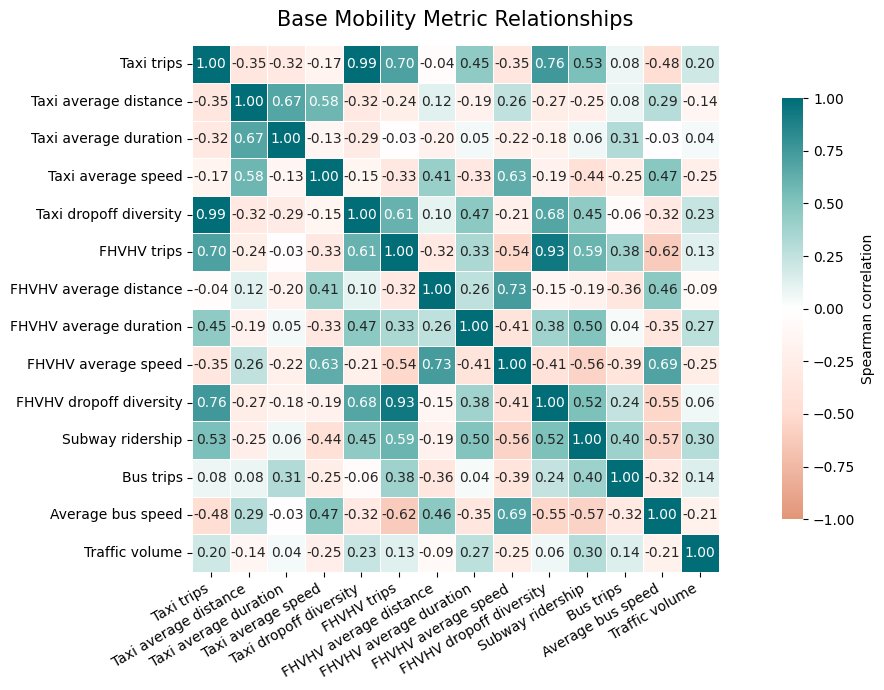

In [6]:
# ---------------------------------------------------------------------
# Visualize correlations across the full base-metric candidate set
# ---------------------------------------------------------------------

heatmap_cmap = LinearSegmentedColormap.from_list(
    "brand_diverging",
    [
        BRAND_COLORS["terracotta"],
        BRAND_COLORS["pale_peach"],
        "#ffffff",
        BRAND_COLORS["seafoam"],
        BRAND_COLORS["dark_teal"],
    ],
)

fig, ax = plt.subplots(figsize=(13, 7))

sns.heatmap(
    base_metric_correlation_display_df,
    annot=True,
    fmt=".2f",
    cmap=heatmap_cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Spearman correlation", "shrink": 0.8},
    ax=ax,
)

ax.set_title("Base Mobility Metric Relationships", fontsize=15, pad=14)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(EDA_OUTPUT_DIR / "base_metric_correlation_heatmap.png", dpi=180, bbox_inches="tight")

plt.show()

This heatmap is useful, but it is still a little dense\. Before we narrow the candidate set, let’s translate it into a simpler overlap screen that flags which candidate metrics are most tightly echoing another signal\. This does not make the keep/remove decision by itself\. It just shows where the strongest redundancy pressure is sitting\.

In [39]:
# ---------------------------------------------------------------------
# Surface the most overlapping same-modality candidate pairs
# ---------------------------------------------------------------------

candidate_metric_list = candidate_metric_inventory_df["metric"].tolist()

same_modality_pair_records = []

for i, metric_x in enumerate(candidate_metric_list):
    for metric_y in candidate_metric_list[i + 1:]:
        family_x = metric_family_lookup.get(metric_x, "")
        family_y = metric_family_lookup.get(metric_y, "")

        modality_x = family_x.split("_")[0] if "_" in family_x else family_x
        modality_y = family_y.split("_")[0] if "_" in family_y else family_y

        if modality_x != modality_y:
            continue

        corr_value = base_metric_correlation_df.loc[metric_x, metric_y]

        same_modality_pair_records.append(
            {
                "metric_x": metric_x,
                "metric_y": metric_y,
                "metric_x_label": METRIC_LABELS[metric_x],
                "metric_y_label": METRIC_LABELS[metric_y],
                "pair_label": f"{METRIC_LABELS[metric_x]} vs {METRIC_LABELS[metric_y]}",
                "metric_family_x": family_x,
                "metric_family_y": family_y,
                "modality": modality_x,
                "spearman_correlation": corr_value,
                "abs_spearman_correlation": abs(corr_value) if pd.notna(corr_value) else np.nan,
            }
        )

same_modality_pair_overlap_df = pd.DataFrame(same_modality_pair_records)

same_modality_pair_overlap_df["overlap_band"] = np.select(
    [
        same_modality_pair_overlap_df["abs_spearman_correlation"] >= 0.85,
        same_modality_pair_overlap_df["abs_spearman_correlation"] >= 0.70,
        same_modality_pair_overlap_df["abs_spearman_correlation"] >= 0.55,
    ],
    [
        "very_high_overlap",
        "high_overlap",
        "moderate_overlap",
    ],
    default="lower_overlap",
)

same_modality_pair_overlap_display_df = (
    same_modality_pair_overlap_df.sort_values(
        ["modality", "abs_spearman_correlation", "pair_label"],
        ascending=[True, False, True],
    )
    .reset_index(drop=True)
    .round(3)
)

display(
    same_modality_pair_overlap_display_df[
        [
            "modality",
            "pair_label",
            "spearman_correlation",
            "abs_spearman_correlation",
            "overlap_band",
        ]
    ]
)

,modality,pair_label,spearman_correlation,abs_spearman_correlation,overlap_band
0,bus,Bus trips vs Average bus speed,-0.321,0.321,lower_overlap
1,fhvhv,FHVHV trips vs FHVHV dropoff diversity,0.930,0.930,very_high_overlap
2,fhvhv,FHVHV average distance vs FHVHV average speed,0.728,0.728,high_overlap
3,fhvhv,FHVHV trips vs FHVHV average speed,-0.537,0.537,lower_overlap
4,fhvhv,FHVHV average speed vs FHVHV dropoff diversity,-0.410,0.410,lower_overlap
5,fhvhv,FHVHV average duration vs FHVHV average speed,-0.406,0.406,lower_overlap
6,fhvhv,FHVHV average duration vs FHVHV dropoff diversity,0.377,0.377,lower_overlap
7,fhvhv,FHVHV trips vs FHVHV average duration,0.333,0.333,lower_overlap
8,fhvhv,FHVHV trips vs FHVHV average distance,-0.317,0.317,lower_overlap
9,fhvhv,FHVHV average distance vs FHVHV average duration,0.260,0.260,lower_overlap


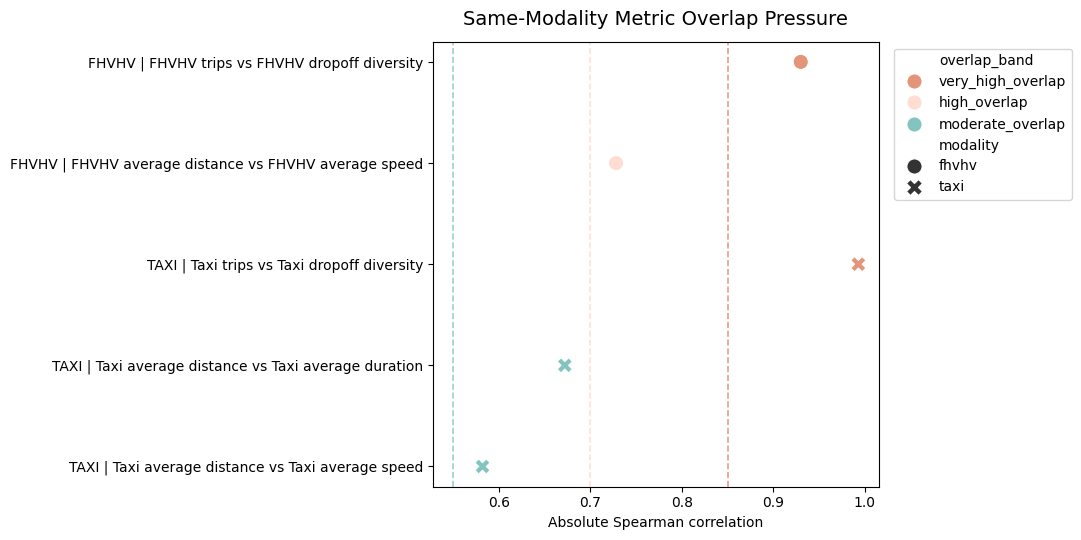

In [8]:
# ---------------------------------------------------------------------
# Visualize same-modality overlap pressure
# ---------------------------------------------------------------------

same_modality_plot_df = (
    same_modality_pair_overlap_df.loc[
        same_modality_pair_overlap_df["abs_spearman_correlation"] >= 0.55
    ]
    .copy()
    .sort_values(
        ["modality", "abs_spearman_correlation"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

same_modality_plot_df["pair_display"] = (
    same_modality_plot_df["modality"].str.upper()
    + " | "
    + same_modality_plot_df["pair_label"]
)

overlap_palette = {
    "very_high_overlap": BRAND_COLORS["terracotta"],
    "high_overlap": BRAND_COLORS["pale_peach"],
    "moderate_overlap": BRAND_COLORS["seafoam"],
}

plt.figure(figsize=(11, max(5.5, len(same_modality_plot_df) * 0.42)))

sns.scatterplot(
    data=same_modality_plot_df,
    x="abs_spearman_correlation",
    y="pair_display",
    hue="overlap_band",
    style="modality",
    palette=overlap_palette,
    s=120,
    edgecolor="white",
    linewidth=0.8,
)

plt.axvline(0.55, color=BRAND_COLORS["seafoam"], linestyle="--", linewidth=1.2, alpha=0.8)
plt.axvline(0.70, color=BRAND_COLORS["pale_peach"], linestyle="--", linewidth=1.2, alpha=0.9)
plt.axvline(0.85, color=BRAND_COLORS["terracotta"], linestyle="--", linewidth=1.2, alpha=0.9)

plt.title("Same-Modality Metric Overlap Pressure", fontsize=14, pad=12)
plt.xlabel("Absolute Spearman correlation")
plt.ylabel("")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        EDA_OUTPUT_DIR / "same_modality_metric_overlap_pressure.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. This same\-modality view makes the shortlist logic much easier to defend\. Within both Taxi and FHVHV, dropoff diversity is so tightly tied to trip volume that it does not earn a place as a recurring backbone metric: Taxi trips vs Taxi dropoff diversity is nearly a perfect overlap, and FHVHV trips vs FHVHV dropoff diversity is almost as strong\. The distance and duration family tells a slightly different story\. Those measures are not as overwhelmingly redundant, but they still cluster closely enough within modality to support trimming them from the recurring notebook backbone, especially since average trip speed is the more interpretable performance signal and was itself derived from the underlying distance and duration ingredients\. That leaves us with a cleaner role\-based metric structure: trip counts as the core activity signals, average speeds as the core surface\-performance signals, dropoff diversity as a richer downstream spatial\-behavior feature, and bus trip count excluded for a separate reason because it is too tied to scheduled service supply rather than clean mobility demand\.

With the full candidate set reviewed, we can narrow to the smaller group that is actually worth repeated visual attention\. The goal here is not to pick the seven biggest columns, but the seven that best balance demand, performance, modality coverage, and interpretability before making the final call on whether \`bus\_trip\_count\` belongs with them\.

In [9]:
# ---------------------------------------------------------------------
# Narrow the full candidate set to the final recurring-visual shortlist
# ---------------------------------------------------------------------

VISUAL_SHORTLIST_CANDIDATES = [
    "taxi_trip_count",
    "taxi_avg_trip_speed",
    "fhvhv_trip_count",
    "fhvhv_avg_trip_speed",
    "subway_ridership",
    "bus_trip_count",
    "avg_bus_speed",
]

shortlist_decision_lookup = {
    "taxi_trip_count": "keep",
    "taxi_avg_trip_speed": "keep",
    "fhvhv_trip_count": "keep",
    "fhvhv_avg_trip_speed": "keep",
    "subway_ridership": "keep",
    "bus_trip_count": "remove_from_recurring_backbone",
    "avg_bus_speed": "keep",
}

shortlist_rationale_lookup = {
    "taxi_trip_count": "clean taxi demand signal",
    "taxi_avg_trip_speed": "surface performance signal",
    "fhvhv_trip_count": "clean FHVHV demand signal",
    "fhvhv_avg_trip_speed": "surface performance signal",
    "subway_ridership": "best transit demand signal",
    "bus_trip_count": "too tied to scheduled service supply",
    "avg_bus_speed": "better bus network conditions signal",
}

visual_shortlist_review_df = pd.DataFrame(
    {
        "metric": VISUAL_SHORTLIST_CANDIDATES,
        "metric_label": [METRIC_LABELS[metric] for metric in VISUAL_SHORTLIST_CANDIDATES],
        "final_decision": [shortlist_decision_lookup[metric] for metric in VISUAL_SHORTLIST_CANDIDATES],
        "rationale": [shortlist_rationale_lookup[metric] for metric in VISUAL_SHORTLIST_CANDIDATES],
    }
)

display(visual_shortlist_review_df)

,metric,metric_label,final_decision,rationale
0,taxi_trip_count,Taxi trips,keep,clean taxi demand signal
1,taxi_avg_trip_speed,Taxi average speed,keep,surface performance signal
2,fhvhv_trip_count,FHVHV trips,keep,clean FHVHV demand signal
3,fhvhv_avg_trip_speed,FHVHV average speed,keep,surface performance signal
4,subway_ridership,Subway ridership,keep,best transit demand signal
5,bus_trip_count,Bus trips,remove_from_recurring_backbone,too tied to scheduled service supply
6,avg_bus_speed,Average bus speed,keep,better bus network conditions signal


> ⚖️ Decision\. After reviewing the full base\-metric candidate set, we narrow to seven serious recurring\-visual candidates: \`taxi\_trip\_count\`, \`taxi\_avg\_trip\_speed\`, \`fhvhv\_trip\_count\`, \`fhvhv\_avg\_trip\_speed\`, \`subway\_ridership\`, \`bus\_trip\_count\`, and \`avg\_bus\_speed\`\. From that group, we drop \`bus\_trip\_count\` from the recurring backbone because it reflects scheduled service supply more than a clean mobility\-state signal\. So the final repeated visual backbone for \`1\.4\.1\` is \`taxi\_trip\_count\`, \`taxi\_avg\_trip\_speed\`, \`fhvhv\_trip\_count\`, \`fhvhv\_avg\_trip\_speed\`, \`subway\_ridership\`, and \`avg\_bus\_speed\`\. This narrows the notebook visuals, not the underlying data or the app’s eventual metric options\.

### Define geography and comparison cuts

We will reuse the spatial context created upstream rather than inventing geography inside the EDA\. The recurring cuts are citywide, borough, and the four \`cbd\_spatial\_category\` groups\. Later zone\-level examples will be selected statistically from the six core metrics, and unusual periods will also be surfaced from observed deviations rather than chosen by hand\.

In [10]:
# ---------------------------------------------------------------------
# Define reusable temporal and spatial comparison cuts
# ---------------------------------------------------------------------

POLICY_GEOGRAPHY_ORDER = [
    "cbd",
    "gateway_to_cbd",
    "adjacent_to_cbd",
    "non_cbd",
]

mobility_panel_df["cbd_spatial_category"] = pd.Categorical(
    mobility_panel_df["cbd_spatial_category"],
    categories=POLICY_GEOGRAPHY_ORDER,
    ordered=True,
)

mobility_panel_df["analysis_period"] = pd.Categorical(
    np.where(
        mobility_panel_df["date"] >= CONGESTION_PRICING_START_DATE,
        "post_cp",
        "pre_cp",
    ),
    categories=["pre_cp", "post_cp"],
    ordered=True,
)

comparison_cut_summary_df = (
    mobility_panel_df[
        ["taxi_zone_id", "zone", "borough", "cbd_spatial_category"]
    ]
    .drop_duplicates("taxi_zone_id")
    .groupby(["borough", "cbd_spatial_category"], observed=True)
    .agg(taxi_zone_count=("taxi_zone_id", "nunique"))
    .reset_index()
    .sort_values(["cbd_spatial_category", "borough"])
)

display(comparison_cut_summary_df)

,borough,cbd_spatial_category,taxi_zone_count
4,Manhattan,cbd,41
1,Brooklyn,gateway_to_cbd,8
3,EWR,gateway_to_cbd,1
7,Queens,gateway_to_cbd,3
5,Manhattan,adjacent_to_cbd,7
0,Bronx,non_cbd,43
2,Brooklyn,non_cbd,53
6,Manhattan,non_cbd,19
8,Queens,non_cbd,66
9,Staten Island,non_cbd,20


### State the notebook question list

This notebook focuses on a small set of temporal and spatial questions that can generate useful insight for later clustering, anomaly detection, supervised learning, and forecasting\. We are not trying to exhaust every possible visualization or repeat broad sanity checks we already handled upstream\. The main questions are:

Citywide temporal shifts and regime shape

Which mobility metrics show the clearest pre/post congestion\-pricing temporal shift at the citywide level?
Are the biggest mobility shifts after congestion pricing immediate, gradual, or temporary?
Are the largest mobility changes concentrated in specific times of day, or spread across the whole day?
Do the daily temporal\-bucket profiles for Taxi, FHVHV, Subway, and Bus look meaningfully different before versus after congestion pricing?
Which mobility metrics show the most stable recurring temporal structure across the study period?
Which mobility metrics show the clearest seasonal structure across the study period?
Are there a few specific date windows or event periods where citywide mobility visibly breaks from its normal temporal pattern?

Spatial concentration and geography shifts

Do Manhattan/CBD zones show visibly different pre/post temporal behavior from the rest of the city for a few core metrics?
Do the same places stand out before and after congestion pricing, or does the geography of activity visibly shift?
Are pre/post changes consistent across the city, or concentrated in a smaller set of zones?

Zone\-level distinctiveness and aggregation loss

Do selected high\-interest Taxi Zones show temporal behavior that differs meaningfully from the citywide pattern?
Do borough\- or Manhattan\-level summaries hide meaningful Taxi Zone variation?

With the source contract, metric backbone, comparison cuts, and question list fixed, the rest of the notebook can stay disciplined\. We will use the six core metrics for repeated comparisons, reuse the upstream policy geography, select zones and unusual periods statistically when those decisions arise, and bring in Weather or Bridge/Tunnel only when they help explain a specific result\.

## 1\.4\.1\.2 Citywide temporal shifts and regime shape

This section looks at how the main mobility metrics behave over time at the citywide level and how those patterns differ before and after congestion pricing\. We want to understand whether the major shifts are large or subtle, immediate or gradual, concentrated in certain parts of the day or spread across the full daily cycle, and whether the core metrics show stable recurring temporal structure that could matter later for anomaly interpretation or forecasting\.

### Build citywide temporal summaries

This subsection creates the shared citywide temporal layer that the rest of the chapter will use\. We are collapsing the Taxi Zone panel into a daily citywide view and a daily citywide temporal\-bucket view so we can look cleanly at regime shifts, daily\-shape changes, seasonality, and unusual periods without re\-aggregating the panel in every later block\.

Let's build the citywide daily and citywide daily\-bucket summaries once so the rest of the chapter can stay focused on interpretation instead of repeated aggregation\. Counts are summed across the city, while speed metrics use weighted citywide averages so the larger activity slices carry the appropriate influence\.

In [11]:
# ---------------------------------------------------------------------
# Build shared citywide daily and citywide daily-bucket temporal summaries
# ---------------------------------------------------------------------

def weighted_average(series, weights):
    valid_mask = series.notna() & weights.notna() & (weights > 0)
    if valid_mask.sum() == 0:
        return np.nan
    return np.average(series.loc[valid_mask], weights=weights.loc[valid_mask])


citywide_metric_weight_lookup = {
    "taxi_avg_trip_speed": "taxi_trip_count",
    "fhvhv_avg_trip_speed": "fhvhv_trip_count",
    "avg_bus_speed": "bus_trip_count",
}

citywide_daily_records = []

for date_value, group_df in mobility_panel_df.groupby("date", observed=True):
    row = {
        "date": pd.Timestamp(date_value),
        "analysis_period": group_df["analysis_period"].iloc[0],
    }

    for metric in CORE_MOBILITY_METRICS:
        if metric in COUNT_METRICS:
            row[metric] = group_df[metric].sum(min_count=1)
        else:
            weight_col = citywide_metric_weight_lookup[metric]
            row[metric] = weighted_average(group_df[metric], group_df[weight_col])

    citywide_daily_records.append(row)

citywide_daily_summary_df = (
    pd.DataFrame(citywide_daily_records)
    .sort_values("date")
    .reset_index(drop=True)
)

citywide_daily_summary_df["month_start"] = (
    citywide_daily_summary_df["date"].dt.to_period("M").dt.to_timestamp()
)
citywide_daily_summary_df["month_of_year"] = citywide_daily_summary_df["date"].dt.month
citywide_daily_summary_df["day_of_week"] = citywide_daily_summary_df["date"].dt.day_name()

citywide_daily_long_df = (
    citywide_daily_summary_df.melt(
        id_vars=["date", "analysis_period", "month_start", "month_of_year", "day_of_week"],
        value_vars=CORE_MOBILITY_METRICS,
        var_name="metric",
        value_name="metric_value",
    )
    .assign(metric_label=lambda df: df["metric"].map(METRIC_LABELS))
)

citywide_daily_bucket_records = []

for group_keys, group_df in mobility_panel_df.groupby(
    ["date", "analysis_period", "temporal_bucket", "temporal_bucket_order"],
    observed=True,
):
    date_value, analysis_period_value, temporal_bucket_value, temporal_bucket_order_value = group_keys

    row = {
        "date": pd.Timestamp(date_value),
        "analysis_period": analysis_period_value,
        "temporal_bucket": temporal_bucket_value,
        "temporal_bucket_order": temporal_bucket_order_value,
    }

    for metric in CORE_MOBILITY_METRICS:
        if metric in COUNT_METRICS:
            row[metric] = group_df[metric].sum(min_count=1)
        else:
            weight_col = citywide_metric_weight_lookup[metric]
            row[metric] = weighted_average(group_df[metric], group_df[weight_col])

    citywide_daily_bucket_records.append(row)

citywide_daily_bucket_summary_df = (
    pd.DataFrame(citywide_daily_bucket_records)
    .sort_values(["date", "temporal_bucket_order"])
    .reset_index(drop=True)
)

citywide_daily_bucket_summary_df["temporal_bucket"] = pd.Categorical(
    citywide_daily_bucket_summary_df["temporal_bucket"],
    categories=TEMPORAL_BUCKET_ORDER,
    ordered=True,
)

citywide_summary_contract_df = pd.DataFrame(
    {
        "metric": [
            "daily_rows",
            "daily_bucket_rows",
            "min_date",
            "max_date",
            "metric_count",
            "temporal_bucket_count",
        ],
        "value": [
            len(citywide_daily_summary_df),
            len(citywide_daily_bucket_summary_df),
            citywide_daily_summary_df["date"].min(),
            citywide_daily_summary_df["date"].max(),
            len(CORE_MOBILITY_METRICS),
            citywide_daily_bucket_summary_df["temporal_bucket"].nunique(),
        ],
    }
)

display(citywide_summary_contract_df)

,metric,value
0,daily_rows,1186
1,daily_bucket_rows,5930
2,min_date,2023-01-01 00:00:00
3,max_date,2026-03-31 00:00:00
4,metric_count,6
5,temporal_bucket_count,10


### Compare pre/post citywide time\-series behavior

Let's start with the broadest view: how each core metric evolves over the study period at the citywide level\. The goal here is to see whether the post\-congestion\-pricing shift looks immediate, gradual, temporary, or barely visible at all once we smooth through the daily noise\.

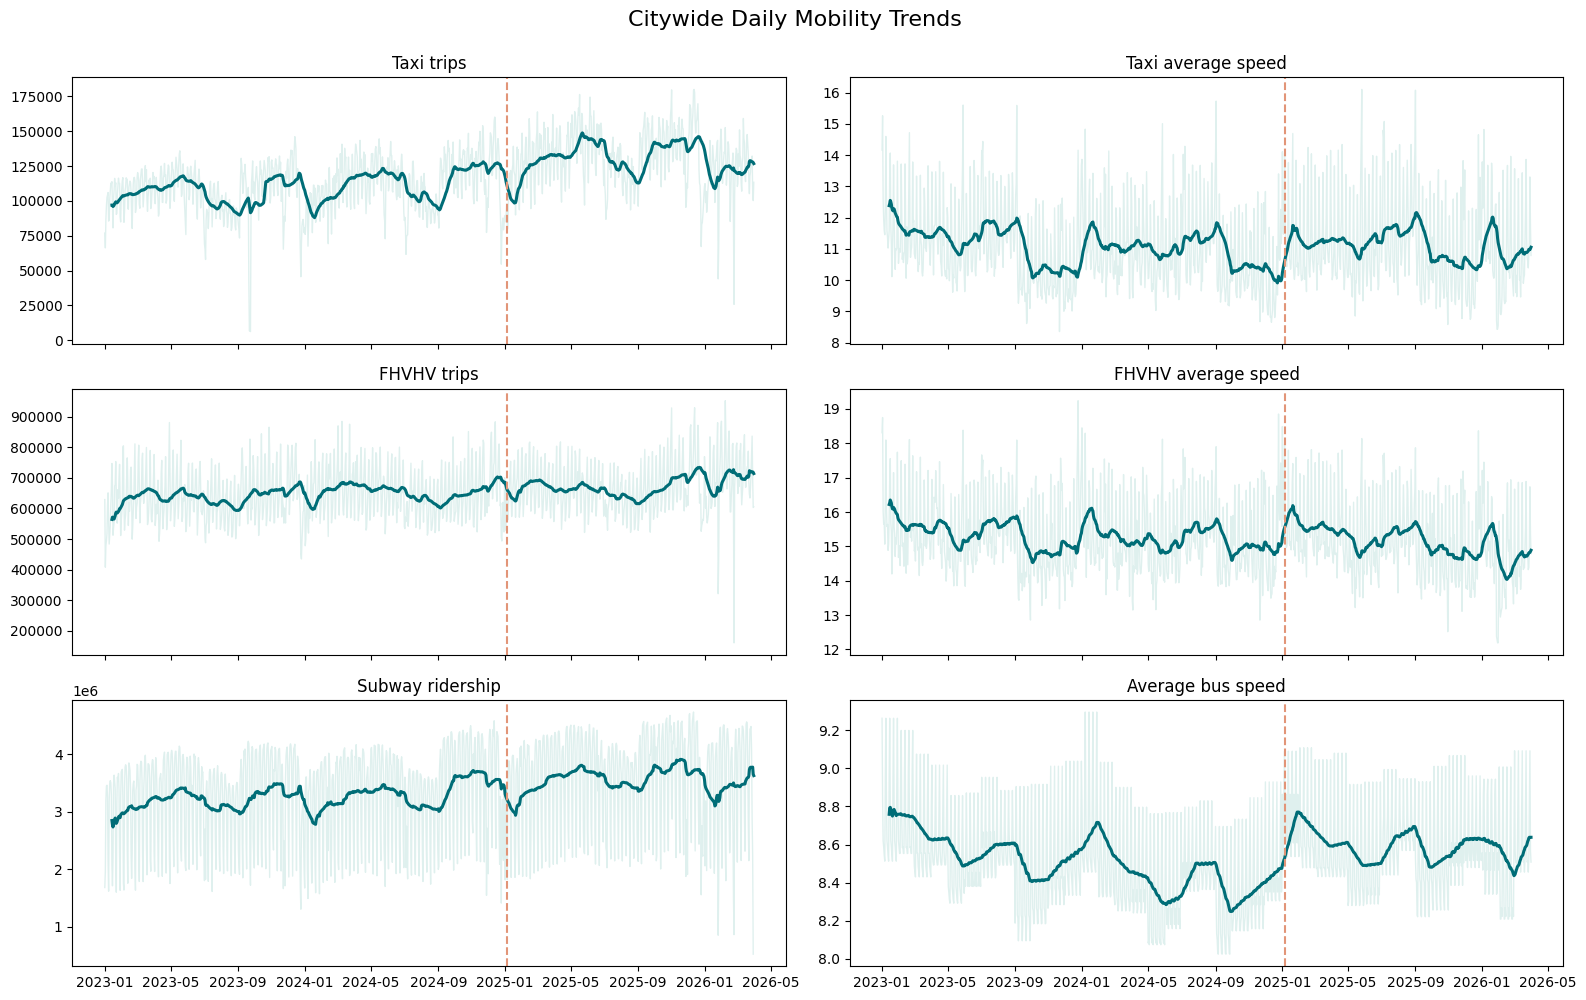

In [12]:
# ---------------------------------------------------------------------
# Plot citywide daily time series with rolling smoothing
# ---------------------------------------------------------------------

citywide_daily_plot_df = citywide_daily_long_df.copy()
citywide_daily_plot_df["rolling_28d"] = (
    citywide_daily_plot_df
    .groupby("metric", observed=True)["metric_value"]
    .transform(lambda s: s.rolling(window=28, min_periods=14).mean())
)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, CORE_MOBILITY_METRICS):
    metric_df = citywide_daily_plot_df.loc[
        citywide_daily_plot_df["metric"] == metric
    ].copy()

    ax.plot(
        metric_df["date"],
        metric_df["metric_value"],
        color=BRAND_COLORS["seafoam"],
        alpha=0.25,
        linewidth=1,
    )
    ax.plot(
        metric_df["date"],
        metric_df["rolling_28d"],
        color=BRAND_COLORS["dark_teal"],
        linewidth=2.2,
    )
    ax.axvline(
        CONGESTION_PRICING_START_DATE,
        color=BRAND_COLORS["terracotta"],
        linestyle="--",
        linewidth=1.5,
    )
    ax.set_title(METRIC_LABELS[metric], fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(CORE_MOBILITY_METRICS):]:
    ax.axis("off")

fig.suptitle("Citywide Daily Mobility Trends", fontsize=16, y=0.995)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        EDA_OUTPUT_DIR / "citywide_daily_mobility_trends.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. The citywide daily trends suggest that congestion pricing did not produce a single uniform regime break across the whole mobility system\. Taxi trips show the clearest upward post\-CP lift, with the smoothed trend rising into a visibly higher band through much of 2025 before easing somewhat later on\. Subway ridership also appears to shift upward after the pricing start, though with more visible seasonal swings layered on top\. FHVHV trips look steadier, with a more modest upward drift than Taxi\. On the performance side, Taxi and FHVHV average speeds do not show a dramatic structural break; if anything, their post\-CP behavior looks fairly continuous with the pre\-CP pattern\. Average bus speed does show a noticeable bump right around the pricing start, but it settles back into its prior range rather than establishing a sharply new long\-run level\. So at the citywide level, the early signal looks more like stronger demand\-side movement than a clean systemwide speed reset\.

Now let's complement the chart with a compact regime\-shift summary\. This keeps us from over\-reading the smoothed lines by checking how the immediate post period and the later stabilized post period compare with the last 90 days before congestion pricing\.

In [13]:
# ---------------------------------------------------------------------
# Summarize immediate and later post-CP shifts versus the last pre-CP window
# ---------------------------------------------------------------------

pre_window_start = CONGESTION_PRICING_START_DATE - pd.Timedelta(days=90)
pre_window_end = CONGESTION_PRICING_START_DATE - pd.Timedelta(days=1)

early_post_start = CONGESTION_PRICING_START_DATE
early_post_end = CONGESTION_PRICING_START_DATE + pd.Timedelta(days=89)

late_post_start = CONGESTION_PRICING_START_DATE + pd.Timedelta(days=180)
late_post_end = min(
    CONGESTION_PRICING_START_DATE + pd.Timedelta(days=364),
    citywide_daily_summary_df["date"].max(),
)

regime_shift_records = []

for metric in CORE_MOBILITY_METRICS:
    pre_values = citywide_daily_summary_df.loc[
        citywide_daily_summary_df["date"].between(pre_window_start, pre_window_end),
        metric,
    ]
    early_post_values = citywide_daily_summary_df.loc[
        citywide_daily_summary_df["date"].between(early_post_start, early_post_end),
        metric,
    ]
    late_post_values = citywide_daily_summary_df.loc[
        citywide_daily_summary_df["date"].between(late_post_start, late_post_end),
        metric,
    ]

    pre_mean = pre_values.mean()
    early_post_mean = early_post_values.mean()
    late_post_mean = late_post_values.mean()

    regime_shift_records.append(
        {
            "metric": metric,
            "metric_label": METRIC_LABELS[metric],
            "pre_90d_mean": pre_mean,
            "early_post_90d_mean": early_post_mean,
            "late_post_mean": late_post_mean,
            "early_post_pct_change": (
                ((early_post_mean - pre_mean) / pre_mean) * 100
                if pd.notna(pre_mean) and pre_mean != 0
                else np.nan
            ),
            "late_post_pct_change": (
                ((late_post_mean - pre_mean) / pre_mean) * 100
                if pd.notna(pre_mean) and pre_mean != 0
                else np.nan
            ),
        }
    )

regime_shift_summary_df = pd.DataFrame(regime_shift_records).round(3)

display(regime_shift_summary_df)

,metric,metric_label,pre_90d_mean,early_post_90d_mean,late_post_mean,early_post_pct_change,late_post_pct_change
0,taxi_trip_count,Taxi trips,120524.167,126291.389,131585.724,4.785,9.178
1,taxi_avg_trip_speed,Taxi average speed,10.419,11.257,11.123,8.045,6.756
2,fhvhv_trip_count,FHVHV trips,663964.667,671360.489,666504.941,1.114,0.383
3,fhvhv_avg_trip_speed,FHVHV average speed,15.133,15.553,15.136,2.776,0.019
4,subway_ridership,Subway ridership,3501458.722,3461112.589,3575825.178,-1.152,2.124
5,avg_bus_speed,Average bus speed,8.419,8.670,8.603,2.983,2.183


Findings\. This windowed pre/post summary sharpens what the trend plots were hinting at\. Taxi shows the clearest and most durable post\-congestion\-pricing shift, with trips up about 4\.8% in the first 90 days and about 9\.2% in the later post period, while Taxi average speed also rises meaningfully and stays elevated\. FHVHV, by contrast, looks much more muted: trips edge up only about 1\.1% early and are basically flat later, while FHVHV speed gets a short\-lived lift that almost fully fades out\. Subway ridership is the one metric that dips slightly right after the pricing start before recovering into modest positive territory later on, which suggests a slower adjustment path than Taxi\. Average bus speed improves a bit both early and later, but the effect size is small compared with the Taxi shift\. So if we had to summarize the citywide regime change in one sentence, it looks strongest and most persistent in Taxi, modest in Bus, mixed but ultimately positive in Subway, and fairly limited in FHVHV\.

Let’s index each metric to its average level in the last 90 pre\-CP days, then follow the monthly path after congestion pricing begins\. This should make it much easier to see which metrics jumped right away, which ones built more gradually, and which ones softened after an initial response\.

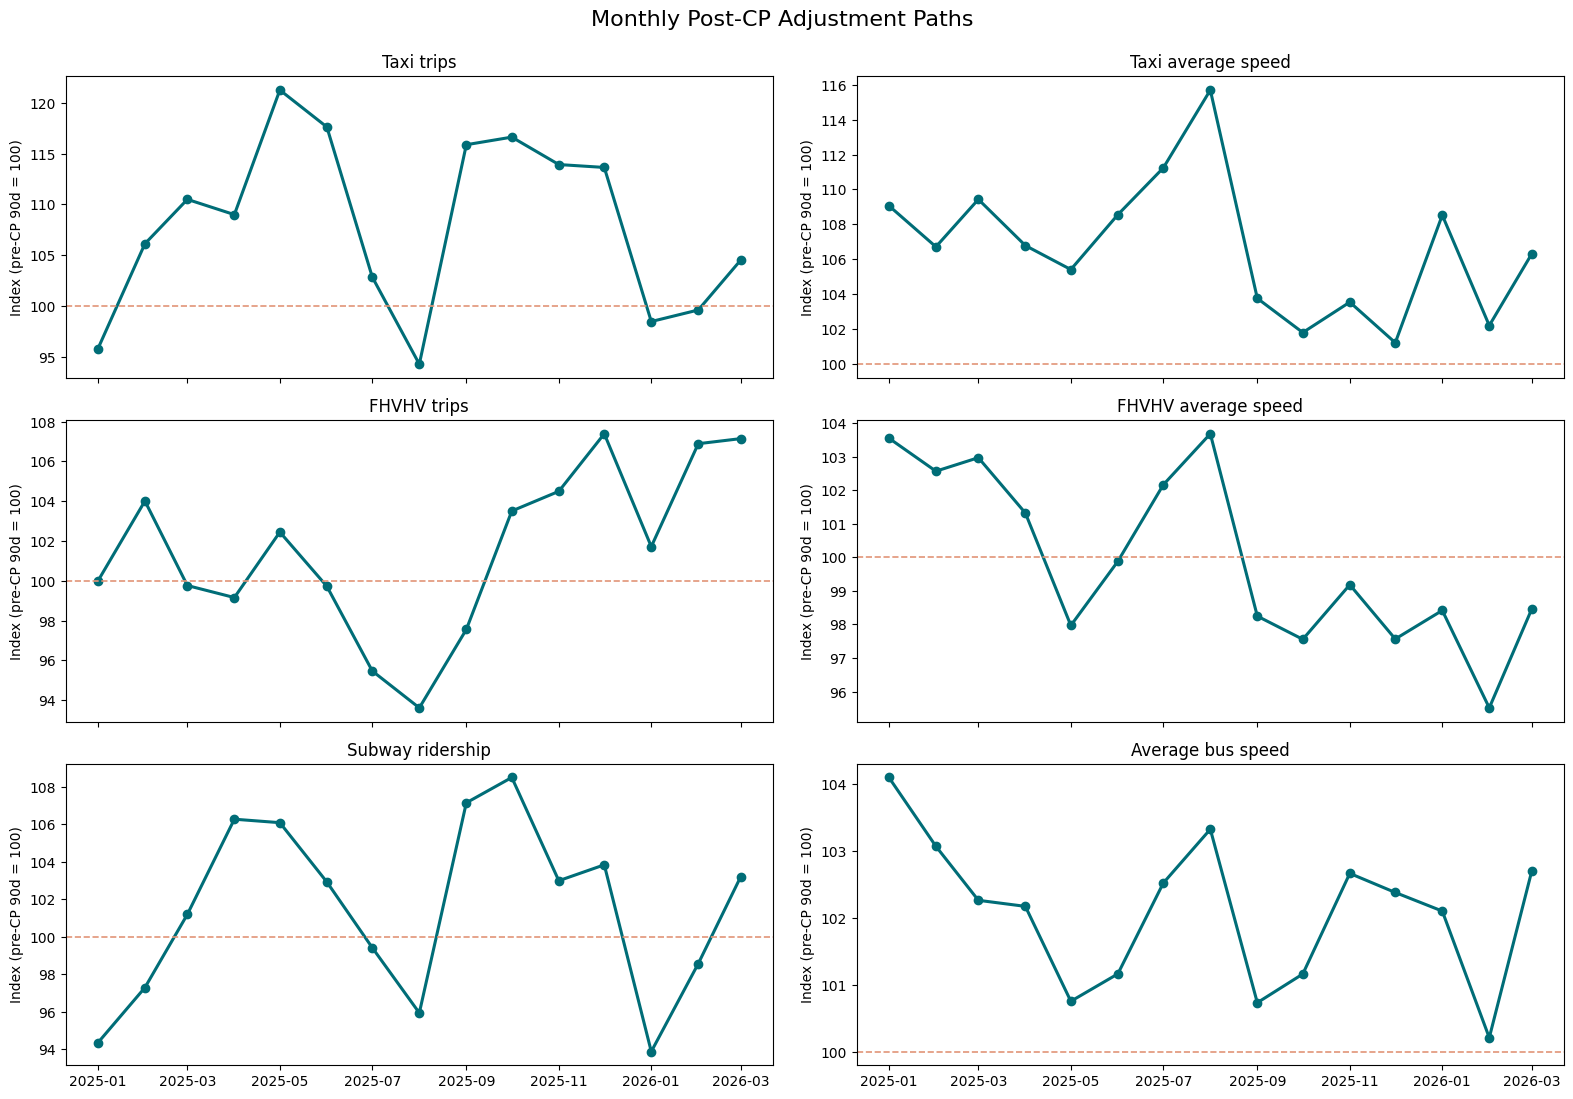

In [14]:
# ---------------------------------------------------------------------
# Visualize monthly post-CP adjustment paths
# ---------------------------------------------------------------------

pre_baseline_lookup = (
    citywide_daily_summary_df.loc[
        citywide_daily_summary_df["date"].between(pre_window_start, pre_window_end),
        ["date", *CORE_MOBILITY_METRICS],
    ][CORE_MOBILITY_METRICS]
    .mean()
    .to_dict()
)

post_cp_monthly_df = (
    citywide_daily_summary_df.loc[
        citywide_daily_summary_df["date"] >= CONGESTION_PRICING_START_DATE
    ]
    .groupby("month_start", observed=True)[CORE_MOBILITY_METRICS]
    .mean()
    .reset_index()
)

post_cp_monthly_long_df = post_cp_monthly_df.melt(
    id_vars=["month_start"],
    value_vars=CORE_MOBILITY_METRICS,
    var_name="metric",
    value_name="metric_value",
)

post_cp_monthly_long_df["metric_label"] = post_cp_monthly_long_df["metric"].map(METRIC_LABELS)
post_cp_monthly_long_df["pre_baseline_value"] = post_cp_monthly_long_df["metric"].map(pre_baseline_lookup)
post_cp_monthly_long_df["indexed_to_pre_baseline"] = np.where(
    post_cp_monthly_long_df["pre_baseline_value"].notna() & (post_cp_monthly_long_df["pre_baseline_value"] != 0),
    (post_cp_monthly_long_df["metric_value"] / post_cp_monthly_long_df["pre_baseline_value"]) * 100,
    np.nan,
)

fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, CORE_MOBILITY_METRICS):
    metric_df = post_cp_monthly_long_df.loc[
        post_cp_monthly_long_df["metric"] == metric
    ].copy()

    ax.plot(
        metric_df["month_start"],
        metric_df["indexed_to_pre_baseline"],
        color=BRAND_COLORS["dark_teal"],
        linewidth=2.2,
        marker="o",
    )
    ax.axhline(100, color=BRAND_COLORS["terracotta"], linestyle="--", linewidth=1.2)
    ax.set_title(METRIC_LABELS[metric], fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Index (pre-CP 90d = 100)")

for ax in axes[len(CORE_MOBILITY_METRICS):]:
    ax.axis("off")

fig.suptitle("Monthly Post-CP Adjustment Paths", fontsize=16, y=0.995)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        EDA_OUTPUT_DIR / "monthly_post_cp_adjustment_paths.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. The monthly adjustment paths show that the post\-congestion\-pricing response was not a one\-time step change with a perfectly steady new level\. Taxi trips and Taxi speed both jump above their pre\-CP baselines fairly quickly and reach their strongest gains in mid\-2025, but those gains fade later on rather than staying at their peak\. FHVHV trips look different: they wobble early, dip below baseline in mid\-2025, then recover and finish stronger later in the post period, which makes that response look more delayed and uneven than Taxi’s\. FHVHV average speed, by contrast, starts slightly positive but weakens over time and ends below baseline, suggesting that any early lift was temporary\. Subway ridership also looks mixed, with an initial dip below baseline, a strong rebound later in 2025, and then another softening before partial recovery\. Average bus speed is the most stable of the six, with only modest movement around a slightly elevated post\-CP level\. Overall, this chart makes the adjustment story feel much more dynamic: Taxi responds early and visibly, FHVHV demand builds later while FHVHV speed fades, Subway recovers after an initially softer period, and Bus remains comparatively steady\.

The chart gives the shape of the adjustment path, and this table gives it a compact label\. We want to know which metrics peaked early, which ones peaked later, and whether the latest post\-CP month is still above, near, or below the initial lift\.

In [15]:
# ---------------------------------------------------------------------
# Summarize monthly post-CP adjustment path behavior
# ---------------------------------------------------------------------

adjustment_path_records = []

for metric in CORE_MOBILITY_METRICS:
    metric_df = post_cp_monthly_long_df.loc[
        post_cp_monthly_long_df["metric"] == metric
    ].sort_values("month_start")

    first_three_mean = metric_df["indexed_to_pre_baseline"].head(3).mean()
    latest_three_mean = metric_df["indexed_to_pre_baseline"].tail(3).mean()
    peak_row = metric_df.loc[metric_df["indexed_to_pre_baseline"].idxmax()]

    adjustment_path_records.append(
        {
            "metric": metric,
            "metric_label": METRIC_LABELS[metric],
            "first_three_post_months_index": first_three_mean,
            "latest_three_post_months_index": latest_three_mean,
            "peak_post_month": peak_row["month_start"],
            "peak_post_month_index": peak_row["indexed_to_pre_baseline"],
            "latest_minus_early_index_points": latest_three_mean - first_three_mean,
        }
    )

adjustment_path_summary_df = pd.DataFrame(adjustment_path_records).round(3)

display(adjustment_path_summary_df)

,metric,metric_label,first_three_post_months_index,latest_three_post_months_index,peak_post_month,peak_post_month_index,latest_minus_early_index_points
0,taxi_trip_count,Taxi trips,104.149,100.880,2025-05-01,121.255,-3.269
1,taxi_avg_trip_speed,Taxi average speed,108.406,105.683,2025-08-01,115.690,-2.723
2,fhvhv_trip_count,FHVHV trips,101.254,105.254,2025-12-01,107.395,4.000
3,fhvhv_avg_trip_speed,FHVHV average speed,103.026,97.465,2025-08-01,103.679,-5.561
4,subway_ridership,Subway ridership,97.610,98.549,2025-10-01,108.498,0.939
5,avg_bus_speed,Average bus speed,103.145,101.670,2025-01-01,104.101,-1.476


Findings\. The monthly adjustment paths show that the post\-CP response was not a simple one\-time level shift\. Taxi trips and Taxi speed rise quickly and peak in mid\-2025, then give back some of those gains later\. FHVHV trips build more gradually and finish stronger later in the post period, while FHVHV average speed fades below baseline over time\. Subway ridership and average bus speed look more moderate and mixed, with Subway recovering after an initially softer period and Bus staying relatively steady throughout\.

### Compare pre/post temporal\-bucket profiles

The daily trend lines show level and slope changes, but they do not tell us whether those changes are concentrated in certain parts of the day\. This next step compares the average citywide temporal\-bucket profile before and after congestion pricing for each core metric so we can see whether the daily shape itself shifted\.

In [16]:
# ---------------------------------------------------------------------
# Build pre/post average temporal-bucket profiles for core metrics
# ---------------------------------------------------------------------

citywide_bucket_profile_df = (
    citywide_daily_bucket_summary_df
    .groupby(["analysis_period", "temporal_bucket", "temporal_bucket_order"], observed=True)[CORE_MOBILITY_METRICS]
    .mean()
    .reset_index()
    .sort_values(["analysis_period", "temporal_bucket_order"])
)

citywide_bucket_profile_long_df = (
    citywide_bucket_profile_df.melt(
        id_vars=["analysis_period", "temporal_bucket", "temporal_bucket_order"],
        value_vars=CORE_MOBILITY_METRICS,
        var_name="metric",
        value_name="metric_value",
    )
    .assign(metric_label=lambda df: df["metric"].map(METRIC_LABELS))
)

bucket_profile_contract_df = pd.DataFrame(
    {
        "metric": [
            "profile_rows",
            "analysis_period_count",
            "temporal_bucket_count",
            "metric_count",
        ],
        "value": [
            len(citywide_bucket_profile_df),
            citywide_bucket_profile_df["analysis_period"].nunique(),
            citywide_bucket_profile_df["temporal_bucket"].nunique(),
            len(CORE_MOBILITY_METRICS),
        ],
    }
)

display(bucket_profile_contract_df)

,metric,value
0,profile_rows,20
1,analysis_period_count,2
2,temporal_bucket_count,10
3,metric_count,6


Let's plot those average bucket profiles side by side\. We want to see whether post\-CP differences are broad all\-day shifts or whether they are concentrated in just a few buckets like weekday AM peak, PM peak, or weekend midday

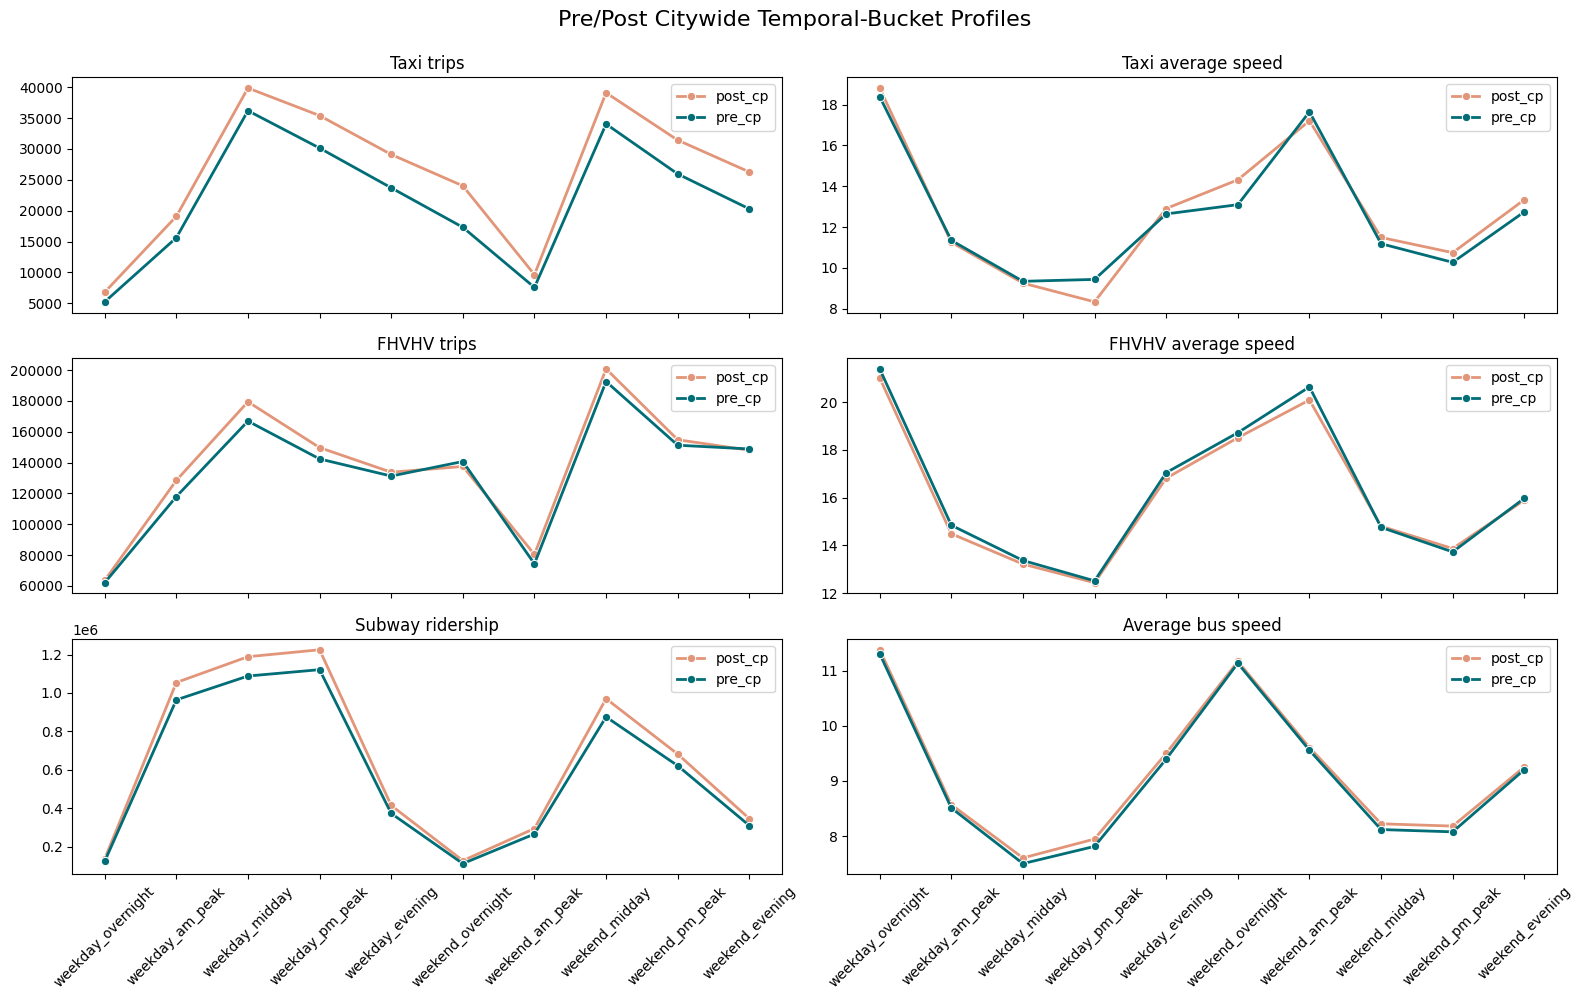

In [17]:
# ---------------------------------------------------------------------
# Plot pre/post citywide temporal-bucket profiles
# ---------------------------------------------------------------------

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, CORE_MOBILITY_METRICS):
    metric_df = citywide_bucket_profile_long_df.loc[
        citywide_bucket_profile_long_df["metric"] == metric
    ].copy()

    sns.lineplot(
        data=metric_df,
        x="temporal_bucket",
        y="metric_value",
        hue="analysis_period",
        palette={
            "pre_cp": BRAND_COLORS["dark_teal"],
            "post_cp": BRAND_COLORS["terracotta"],
        },
        marker="o",
        linewidth=2,
        ax=ax,
    )

    ax.set_title(METRIC_LABELS[metric], fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.legend_.set_title("")

for ax in axes[len(CORE_MOBILITY_METRICS):]:
    ax.axis("off")

fig.suptitle("Pre/Post Citywide Temporal-Bucket Profiles", fontsize=16, y=0.995)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        EDA_OUTPUT_DIR / "pre_post_temporal_bucket_profiles.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. The pre/post bucket profiles suggest that congestion\-pricing effects are not evenly distributed across the day\. Taxi shows the clearest broad uplift, with post\-CP levels running above pre\-CP across nearly every bucket and especially strong separation on weekends, which reinforces the earlier citywide trend result that Taxi is where the most visible demand shift is happening\. Subway ridership also shows a pretty consistent upward post\-CP shift, especially in the weekday commute buckets, while FHVHV trips rise more modestly and mostly preserve the same overall daily shape\. On the performance side, Taxi average speed improves in several buckets, with the clearest lift overnight and into the evening, whereas FHVHV average speed is flatter and even softens in a few buckets\. Average bus speed moves only slightly, with a small but fairly coherent upward shift\. So the main story here is that the daily shape largely survives, but the level shifts are concentrated more strongly in Taxi and Subway than in FHVHV or Bus\.

A compact summary table helps us call out the strongest bucket\-level changes without forcing the reader to eyeball every panel\. This is where we can quickly see which bucket moved the most for each metric and whether the biggest shift was upward or downward\.

In [18]:
# ---------------------------------------------------------------------
# Summarize the strongest temporal-bucket shift for each metric
# ---------------------------------------------------------------------

bucket_change_records = []

for metric in CORE_MOBILITY_METRICS:
    metric_df = citywide_bucket_profile_long_df.loc[
        citywide_bucket_profile_long_df["metric"] == metric,
        ["analysis_period", "temporal_bucket", "temporal_bucket_order", "metric_value"],
    ].copy()

    metric_pivot_df = (
        metric_df.pivot(
            index=["temporal_bucket", "temporal_bucket_order"],
            columns="analysis_period",
            values="metric_value",
        )
        .reset_index()
        .sort_values("temporal_bucket_order")
    )

    metric_pivot_df["absolute_change"] = (
        metric_pivot_df["post_cp"] - metric_pivot_df["pre_cp"]
    )
    metric_pivot_df["pct_change"] = np.where(
        metric_pivot_df["pre_cp"].notna() & (metric_pivot_df["pre_cp"] != 0),
        ((metric_pivot_df["post_cp"] - metric_pivot_df["pre_cp"]) / metric_pivot_df["pre_cp"]) * 100,
        np.nan,
    )

    top_row = metric_pivot_df.loc[
        metric_pivot_df["absolute_change"].abs().idxmax()
    ]

    bucket_change_records.append(
        {
            "metric": metric,
            "metric_label": METRIC_LABELS[metric],
            "largest_shift_bucket": top_row["temporal_bucket"],
            "pre_cp_value": top_row["pre_cp"],
            "post_cp_value": top_row["post_cp"],
            "absolute_change": top_row["absolute_change"],
            "pct_change": top_row["pct_change"],
        }
    )

bucket_change_summary_df = pd.DataFrame(bucket_change_records).round(3)

display(bucket_change_summary_df)

,metric,metric_label,largest_shift_bucket,pre_cp_value,post_cp_value,absolute_change,pct_change
0,taxi_trip_count,Taxi trips,weekend_overnight,17303.824,24023.806,6719.982,38.835
1,taxi_avg_trip_speed,Taxi average speed,weekend_overnight,13.097,14.315,1.218,9.300
2,fhvhv_trip_count,FHVHV trips,weekday_midday,166907.444,179445.873,12538.429,7.512
3,fhvhv_avg_trip_speed,FHVHV average speed,weekend_am_peak,20.632,20.086,-0.547,-2.649
4,subway_ridership,Subway ridership,weekday_pm_peak,1121303.790,1224882.662,103578.872,9.237
5,avg_bus_speed,Average bus speed,weekday_pm_peak,7.812,7.946,0.134,1.712


Findings\. The bucket\-level summary makes the concentration of those shifts more concrete\. Taxi’s biggest move is weekend\_overnight, where trips jump by about 38\.8% and Taxi speed also rises by about 9\.3%, which is a pretty striking combination of stronger activity and better movement\. Subway’s largest change lands in weekday\_pm\_peak, up about 9\.2%, which fits the idea that the transit response is tied more to core weekday commuting structure than to nightlife or off\-peak behavior\. FHVHV’s largest trip increase is more modest at weekday\_midday, and its biggest speed shift is actually negative in weekend\_am\_peak, which again makes FHVHV look less like the main winner from the regime change\. Bus speed’s largest shift is positive but small, only about 1\.7% in weekday\_pm\_peak\. Put together, the table reinforces that the strongest bucket\-level gains are concentrated in Taxi first, Subway second, with FHVHV and Bus showing much lighter movement\.

This gives us a more compact read on the same bucket\-shape question\. Instead of scanning six separate line charts, we can see at a glance which metrics moved most strongly in which temporal buckets after congestion pricing\.

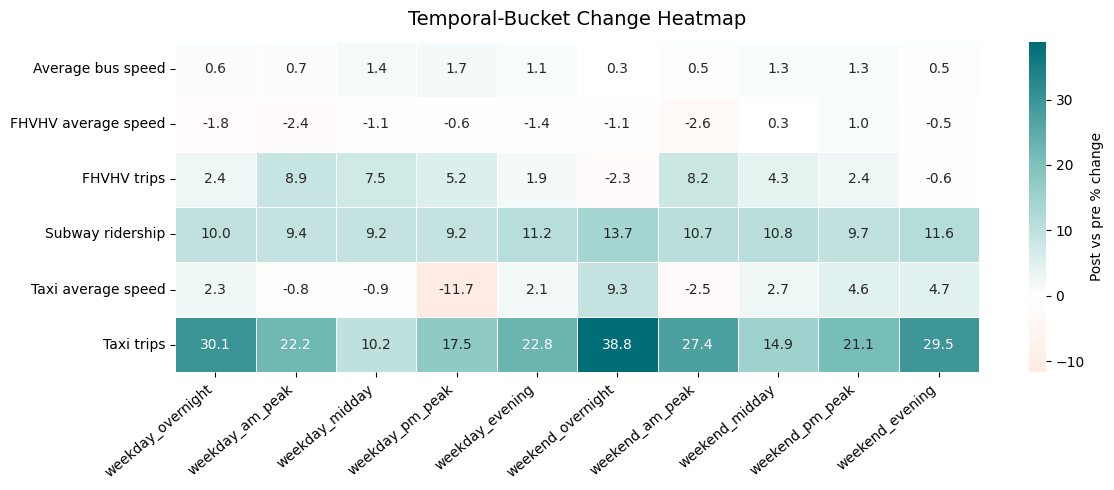

In [19]:
# ---------------------------------------------------------------------
# Visualize pre/post temporal-bucket change as a heatmap
# ---------------------------------------------------------------------

bucket_change_heatmap_df = []

for metric in CORE_MOBILITY_METRICS:
    metric_df = (
        citywide_bucket_profile_long_df.loc[
            citywide_bucket_profile_long_df["metric"] == metric,
            ["analysis_period", "temporal_bucket", "temporal_bucket_order", "metric_value"],
        ]
        .pivot(
            index=["temporal_bucket", "temporal_bucket_order"],
            columns="analysis_period",
            values="metric_value",
        )
        .reset_index()
        .sort_values("temporal_bucket_order")
    )

    metric_df["pct_change"] = np.where(
        metric_df["pre_cp"].notna() & (metric_df["pre_cp"] != 0),
        ((metric_df["post_cp"] - metric_df["pre_cp"]) / metric_df["pre_cp"]) * 100,
        np.nan,
    )
    metric_df["metric_label"] = METRIC_LABELS[metric]
    bucket_change_heatmap_df.append(metric_df[["metric_label", "temporal_bucket", "temporal_bucket_order", "pct_change"]])

bucket_change_heatmap_df = pd.concat(bucket_change_heatmap_df, ignore_index=True)

bucket_change_heatmap_pivot_df = (
    bucket_change_heatmap_df
    .pivot(index="metric_label", columns="temporal_bucket", values="pct_change")
    .reindex(columns=TEMPORAL_BUCKET_ORDER)
)

heatmap_cmap = LinearSegmentedColormap.from_list(
    "brand_diverging_bucket_change",
    [
        BRAND_COLORS["terracotta"],
        BRAND_COLORS["pale_peach"],
        "#ffffff",
        BRAND_COLORS["seafoam"],
        BRAND_COLORS["dark_teal"],
    ],
)

plt.figure(figsize=(12, 5))
sns.heatmap(
    bucket_change_heatmap_pivot_df,
    annot=True,
    fmt=".1f",
    cmap=heatmap_cmap,
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Post vs pre % change"},
)
plt.title("Temporal-Bucket Change Heatmap", fontsize=14, pad=12)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        EDA_OUTPUT_DIR / "temporal_bucket_change_heatmap.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. This heatmap makes the temporal regime shift much easier to read\. Taxi trips are the standout story by far, with strong positive growth in every bucket and especially large jumps overnight and on weekends, which suggests that the post\-CP Taxi response was broad but not uniform across the day\. Subway ridership is the next clearest winner, showing a remarkably consistent lift of roughly 9% to 14% across all buckets, with the strongest gains in weekend overnight and weekday evening periods\. FHVHV trips rise more modestly and unevenly, with gains concentrated in AM, midday, and weekend AM buckets, while FHVHV average speed is slightly negative in most buckets and never shows the kind of broad improvement Taxi does\. Average bus speed edges up almost everywhere, but only by small amounts\. Taxi average speed is the most mixed row: it improves meaningfully overnight and on weekends, but it actually drops sharply in weekday PM peak, which hints that Taxi’s demand growth and Taxi’s speed response were not moving together in every part of the day\.

### Inspect recurring and seasonal temporal structure

With the regime\-shift views in place, we can step back and ask which metrics seem to have stable recurring seasonal structure\. This is less about congestion pricing directly and more about understanding whether the series have strong month\-of\-year rhythm that later notebooks should respect\.

In [20]:
# ---------------------------------------------------------------------
# Build month-of-year seasonal summaries for the core metrics
# ---------------------------------------------------------------------

month_name_lookup = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}

citywide_month_of_year_profile_df = (
    citywide_daily_long_df
    .groupby(["metric", "metric_label", "month_of_year"], observed=True)
    .agg(
        average_value=("metric_value", "mean"),
        median_value=("metric_value", "median"),
        observation_days=("metric_value", "size"),
    )
    .reset_index()
    .sort_values(["metric", "month_of_year"])
)

citywide_month_of_year_profile_df["month_name"] = (
    citywide_month_of_year_profile_df["month_of_year"].map(month_name_lookup)
)

seasonality_contract_df = pd.DataFrame(
    {
        "metric": [
            "seasonality_rows",
            "distinct_metrics",
            "distinct_months",
        ],
        "value": [
            len(citywide_month_of_year_profile_df),
            citywide_month_of_year_profile_df["metric"].nunique(),
            citywide_month_of_year_profile_df["month_of_year"].nunique(),
        ],
    }
)

display(seasonality_contract_df)

,metric,value
0,seasonality_rows,72
1,distinct_metrics,6
2,distinct_months,12


Let's plot the month\-of\-year profiles directly\. The point here is to see whether the series have stable seasonal rhythm and whether that rhythm looks strong enough that later anomaly or forecasting work should treat seasonality as a first\-order part of the signal rather than background noise\.

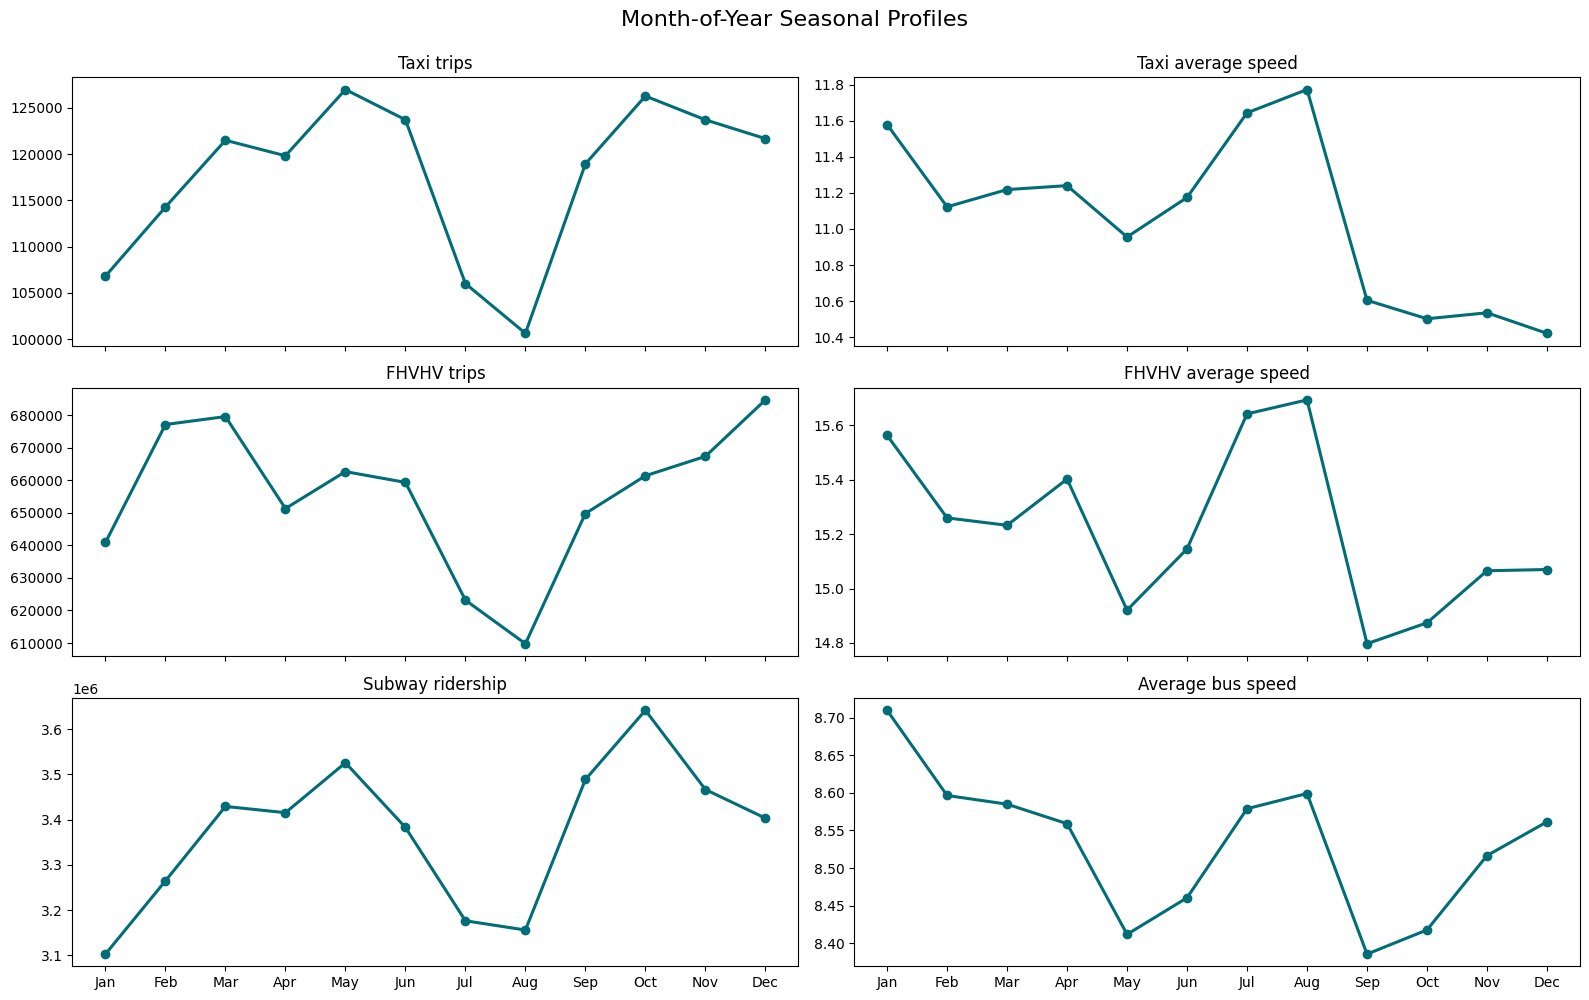

In [21]:
# ---------------------------------------------------------------------
# Plot month-of-year seasonal profiles
# ---------------------------------------------------------------------

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, CORE_MOBILITY_METRICS):
    metric_df = citywide_month_of_year_profile_df.loc[
        citywide_month_of_year_profile_df["metric"] == metric
    ].copy()

    ax.plot(
        metric_df["month_name"],
        metric_df["average_value"],
        color=BRAND_COLORS["dark_teal"],
        marker="o",
        linewidth=2.2,
    )
    ax.set_title(METRIC_LABELS[metric], fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(CORE_MOBILITY_METRICS):]:
    ax.axis("off")

fig.suptitle("Month-of-Year Seasonal Profiles", fontsize=16, y=0.995)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        EDA_OUTPUT_DIR / "month_of_year_seasonal_profiles.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. The month\-of\-year profiles suggest that all six core metrics carry real seasonal structure, but not all in the same way\. Taxi, FHVHV, and Subway all dip sharply in mid\-to\-late summer, especially around July and August, then recover into a stronger fall pattern, which is a pretty clear signal that later anomaly or forecasting work should not treat those months as interchangeable with spring or autumn\. Taxi and FHVHV speeds also show a seasonal split, with stronger values in the summer and weaker values in the fall and winter, while average bus speed follows a milder version of that same pattern\. So the main takeaway here is that seasonality is real and fairly coherent across the system, but it expresses itself differently in demand versus speed metrics\.

We want a simple way to compare how consistently each metric repeats its usual within\-day shape from month to month\. Instead of plotting raw similarity scores that all bunch up near 1, this view flips the measure into instability, where lower values mean the metric’s monthly temporal\-bucket profile stays closer to its long\-run pattern and higher values mean the shape drifts more over time\.

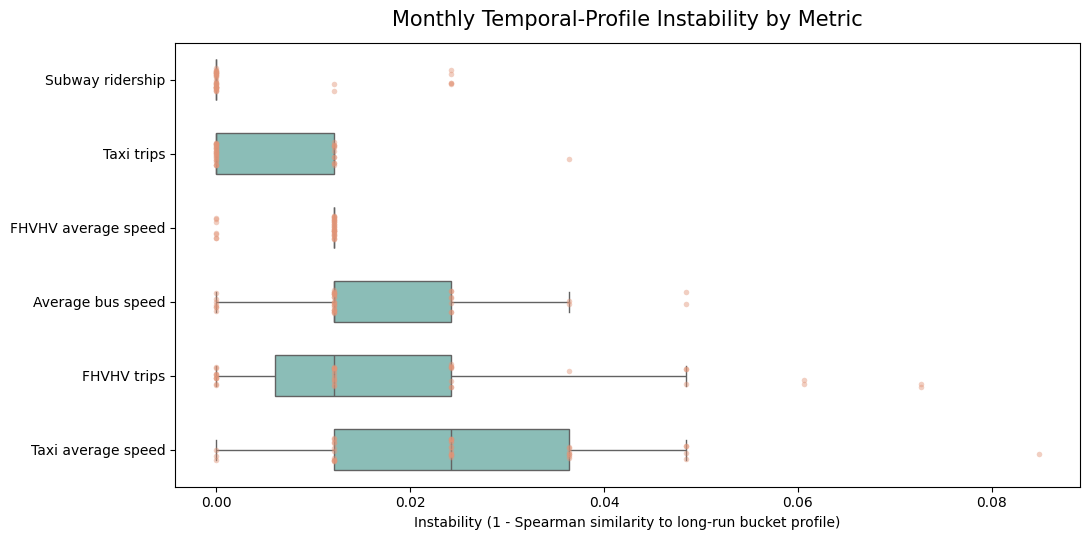

In [22]:
# ---------------------------------------------------------------------
# Visualize recurring temporal-profile instability across metrics
# ---------------------------------------------------------------------

monthly_bucket_profile_df = (
    mobility_panel_df.groupby(
        ["year", "month", "temporal_bucket", "temporal_bucket_order"],
        observed=True,
    )[CORE_MOBILITY_METRICS]
    .mean()
    .reset_index()
)

monthly_bucket_profile_long_df = monthly_bucket_profile_df.melt(
    id_vars=["year", "month", "temporal_bucket", "temporal_bucket_order"],
    value_vars=CORE_MOBILITY_METRICS,
    var_name="metric",
    value_name="metric_value",
)

monthly_bucket_profile_long_df["profile_index"] = (
    monthly_bucket_profile_long_df.groupby(
        ["year", "month", "metric"],
        observed=True,
    )["metric_value"].transform(lambda s: (s / s.mean()) * 100 if s.notna().any() else np.nan)
)

long_run_bucket_profile_df = (
    monthly_bucket_profile_long_df.groupby(
        ["metric", "temporal_bucket", "temporal_bucket_order"],
        observed=True,
    )["profile_index"]
    .mean()
    .reset_index(name="long_run_profile_index")
)

monthly_profile_similarity_df = (
    monthly_bucket_profile_long_df.merge(
        long_run_bucket_profile_df,
        on=["metric", "temporal_bucket", "temporal_bucket_order"],
        how="left",
    )
    .groupby(["year", "month", "metric"], observed=True)
    .apply(
        lambda df: pd.Series(
            {
                "monthly_profile_similarity": df["profile_index"].corr(
                    df["long_run_profile_index"],
                    method="spearman",
                )
            }
        )
    )
    .reset_index()
)

monthly_profile_similarity_df["profile_instability"] = (
    1 - monthly_profile_similarity_df["monthly_profile_similarity"]
)

monthly_profile_similarity_df["metric_label"] = (
    monthly_profile_similarity_df["metric"].map(METRIC_LABELS)
)

monthly_profile_similarity_df = monthly_profile_similarity_df.dropna(
    subset=["profile_instability"]
).copy()

metric_order = (
    monthly_profile_similarity_df.groupby("metric_label", observed=True)["profile_instability"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(11, 5.5))

sns.boxplot(
    data=monthly_profile_similarity_df,
    y="metric_label",
    x="profile_instability",
    order=metric_order,
    color=BRAND_COLORS["seafoam"],
    width=0.55,
    fliersize=0,
)

sns.stripplot(
    data=monthly_profile_similarity_df,
    y="metric_label",
    x="profile_instability",
    order=metric_order,
    color=BRAND_COLORS["terracotta"],
    alpha=0.45,
    size=4,
    jitter=0.16,
)

plt.title("Monthly Temporal-Profile Instability by Metric", fontsize=15, pad=12)
plt.xlabel("Instability (1 - Spearman similarity to long-run bucket profile)")
plt.ylabel("")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        EDA_OUTPUT_DIR / "monthly_temporal_profile_instability.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. This view suggests that all six metrics have fairly stable monthly within\-day structure overall, but not equally so\. Subway ridership is the tightest and most stable pattern, with almost all months clustered very close to zero instability\. Taxi trips also look quite stable, though with a somewhat wider spread and a small number of more unusual months\. Average bus speed and FHVHV trips show more month\-to\-month variation in their temporal shape, while Taxi average speed has the widest spread of all, indicating the most drift from its usual within\-day pattern\. FHVHV average speed is mostly stable as well, but with a few isolated departures\. So the main takeaway is that recurring temporal structure is strongest for Subway ridership and Taxi trips, while the speed metrics, especially Taxi average speed, vary more from month to month\.

One last pass here is to surface a few statistically unusual citywide days instead of picking them by hand\. This gives us a clean handoff into later sections if certain windows turn out to deserve a closer spatial or zone\-level look\.

In [23]:
# ---------------------------------------------------------------------
# Flag statistically unusual citywide days by metric
# ---------------------------------------------------------------------

unusual_period_records = []

for metric in CORE_MOBILITY_METRICS:
    metric_df = citywide_daily_summary_df[["date", metric]].copy()
    metric_df["rolling_56d_median"] = metric_df[metric].rolling(window=56, min_periods=28).median()
    metric_df["rolling_56d_std"] = metric_df[metric].rolling(window=56, min_periods=28).std()
    metric_df["standardized_deviation"] = (
        (metric_df[metric] - metric_df["rolling_56d_median"]) /
        metric_df["rolling_56d_std"]
    )

    metric_top_df = (
        metric_df.loc[metric_df["standardized_deviation"].notna(), ["date", metric, "standardized_deviation"]]
        .assign(metric=metric, metric_label=METRIC_LABELS[metric])
        .rename(columns={metric: "metric_value"})
    )

    metric_top_df["abs_standardized_deviation"] = metric_top_df["standardized_deviation"].abs()

    metric_top_df = (
        metric_top_df
        .sort_values("abs_standardized_deviation", ascending=False)
        .head(3)
        .drop(columns="abs_standardized_deviation")
        .reindex(columns=["metric", "metric_label", "date", "metric_value", "standardized_deviation"])
    )

    unusual_period_records.append(metric_top_df)

citywide_unusual_periods_df = (
    pd.concat(unusual_period_records, ignore_index=True)
    .sort_values(["metric_label", "standardized_deviation"], ascending=[True, False])
    .reset_index(drop=True)
    .round(3)
)

display(citywide_unusual_periods_df)

,metric,metric_label,date,metric_value,standardized_deviation
0,avg_bus_speed,Average bus speed,2024-01-07,9.296,3.304
1,avg_bus_speed,Average bus speed,2024-01-14,9.296,3.135
2,avg_bus_speed,Average bus speed,2025-01-05,9.090,2.995
3,fhvhv_avg_trip_speed,FHVHV average speed,2023-12-25,19.240,3.738
4,fhvhv_avg_trip_speed,FHVHV average speed,2025-12-25,18.364,3.356
5,fhvhv_avg_trip_speed,FHVHV average speed,2024-12-25,18.852,3.337
6,fhvhv_trip_count,FHVHV trips,2024-09-28,833711.000,3.052
7,fhvhv_trip_count,FHVHV trips,2026-01-25,321508.000,-3.317
8,fhvhv_trip_count,FHVHV trips,2026-02-23,160777.000,-3.899
9,subway_ridership,Subway ridership,2026-02-23,861361.000,-2.890


Findings\. These unusual\-day flags mostly make sense and they help separate real structure from obvious calendar or data\-disruption effects\. The strongest positive speed outliers cluster around holiday\-style low\-congestion days, especially Christmas for FHVHV speed and early\-January Sundays for bus speed, while Taxi speed also spikes on holiday dates like Memorial Day and Labor Day\. On the negative side, the biggest drops are concentrated in late\-study dates like January through March 2026 for Taxi trips, FHVHV trips, and Subway ridership, which looks less like organic mobility behavior and more like incomplete or abnormal end\-of\-series observations that we should treat cautiously\. Thanksgiving also stands out as a sharp negative Taxi trip day, which feels behaviorally plausible rather than suspicious\. So the useful takeaway is that this quick flagging step is surfacing a mix of real holiday effects and probable late\-period data artifacts, which gives us a cleaner sense of which “unusual periods” are worth revisiting later and which ones we should not over\-interpret\.

The visual shows the spread, but this table makes the ranking explicit\. We want a simple summary of typical month\-to\-month profile similarity and how much it varies so we can say more confidently which metrics have the most stable recurring temporal structure\.

In [24]:
# ---------------------------------------------------------------------
# Summarize recurring temporal-profile stability
# ---------------------------------------------------------------------

monthly_profile_stability_summary_df = (
    monthly_profile_similarity_df.groupby(
        ["metric", "metric_label"],
        observed=True,
    )["monthly_profile_similarity"]
    .agg(
        median_profile_similarity="median",
        p10_profile_similarity=lambda s: s.quantile(0.10),
        p90_profile_similarity=lambda s: s.quantile(0.90),
        std_profile_similarity="std",
    )
    .reset_index()
    .sort_values("median_profile_similarity", ascending=False)
    .round(3)
)

display(monthly_profile_stability_summary_df)

,metric,metric_label,median_profile_similarity,p10_profile_similarity,p90_profile_similarity,std_profile_similarity
5,taxi_trip_count,Taxi trips,1.000,0.988,1.000,0.008
3,subway_ridership,Subway ridership,1.000,0.976,1.000,0.008
1,fhvhv_avg_trip_speed,FHVHV average speed,0.988,0.988,1.000,0.005
0,avg_bus_speed,Average bus speed,0.988,0.973,1.000,0.012
2,fhvhv_trip_count,FHVHV trips,0.988,0.949,1.000,0.021
4,taxi_avg_trip_speed,Taxi average speed,0.976,0.952,0.988,0.017


Findings\. The summary table reinforces that recurring temporal structure is very strong across all six metrics, with median month\-to\-month profile similarity at 0\.976 or higher in every case\. Subway ridership and Taxi trips are the most repeatable patterns, both with a median similarity of 1\.000 and very tight lower\-tail values, which means their monthly temporal\-bucket shapes stay extremely close to their long\-run structure almost all the time\. Average bus speed and FHVHV average speed are also highly stable, while FHVHV trips and especially Taxi average speed show somewhat more variation, reflected in their wider lower\-tail spread and higher standard deviations\. So the main takeaway is that all six series are structurally orderly, but Subway ridership and Taxi trips are the cleanest recurring temporal patterns, while Taxi speed and FHVHV demand drift a bit more from month to month\.

### Section Summary

At the citywide level, the clearest post\-congestion\-pricing movement shows up in Taxi first, Subway second, with FHVHV and Bus moving more modestly\. The daily trend and regime\-shift views suggest that demand changed more visibly than systemwide speeds did, while the bucket\-profile comparisons show those changes were not evenly distributed across the day, with some of the strongest lifts concentrated in specific commute or weekend buckets\. The seasonal view also makes it clear that these series carry real recurring structure, especially around summer dips and fall recovery, so later notebooks should treat seasonality as part of the signal rather than background noise\. And finally, the unusual\-day scan helps us distinguish plausible holiday effects from suspicious late\-period drops, which is useful context before we move into the more spatial parts of the notebook\.

## 1\.4\.1\.3 Spatial concentration and geography shifts

This section shifts from citywide time patterns to spatial concentration\. We are asking where the strongest mobility levels and changes are showing up, whether those shifts stay concentrated in Manhattan/CBD\-oriented areas or spread more broadly, and whether a simple policy\-geography lens surfaces differences that the citywide view cannot\.

### Build pre/post spatial aggregates for selected metrics

Let’s build one clean zone\-level spatial summary that the rest of the section can reuse\. We’ll average each core metric within the pre\-CP and post\-CP periods at the Taxi Zone level, then attach geometry once so the baseline maps, change maps, and policy\-geography comparisons all work off the same shared layer\.

In [25]:
# ---------------------------------------------------------------------
# Build shared pre/post Taxi Zone spatial summaries for the core metrics
# ---------------------------------------------------------------------

zone_reference_df = pd.read_parquet(TAXI_ZONE_SPATIAL_CONTEXT_PATH).copy()

spatial_join_key = (
    "canonical_location_id"
    if "canonical_location_id" in zone_reference_df.columns
    else "location_id"
)

zone_reference_df = zone_reference_df.loc[
    zone_reference_df[spatial_join_key].notna() & zone_reference_df["geometry"].notna()
].copy()

zone_reference_df[spatial_join_key] = zone_reference_df[spatial_join_key].astype(int)

zone_reference_df["geometry"] = zone_reference_df["geometry"].apply(
    lambda geom: wkb.loads(geom) if isinstance(geom, (bytes, bytearray)) else geom
)

zone_geometry_gdf = (
    gpd.GeoDataFrame(zone_reference_df, geometry="geometry", crs="EPSG:4326")
    .drop_duplicates(subset=[spatial_join_key])
    .copy()
)

zone_spatial_period_summary_df = (
    mobility_panel_df.groupby(
        [spatial_join_key, "zone", "borough", "cbd_spatial_category", "analysis_period"],
        observed=True,
    )[CORE_MOBILITY_METRICS]
    .mean()
    .reset_index()
)

zone_spatial_period_gdf = zone_geometry_gdf.merge(
    zone_spatial_period_summary_df,
    on=spatial_join_key,
    how="inner",
)

zone_spatial_period_contract_df = pd.DataFrame(
    {
        "metric": [
            "zone_period_rows",
            "zone_count",
            "analysis_period_count",
            "metric_count",
        ],
        "value": [
            len(zone_spatial_period_gdf),
            zone_spatial_period_gdf[spatial_join_key].nunique(),
            zone_spatial_period_gdf["analysis_period"].nunique(),
            len(CORE_MOBILITY_METRICS),
        ],
    }
)

display(zone_spatial_period_contract_df)

,metric,value
0,zone_period_rows,520
1,zone_count,260
2,analysis_period_count,2
3,metric_count,6


### Map baseline spatial activity patterns

Start with the pre\-CP baseline so we know what “normal” spatial concentration looked like before we interpret change\. These maps are meant to answer a simple question first: where were the core mobility signals already strongest or weakest before pricing started?

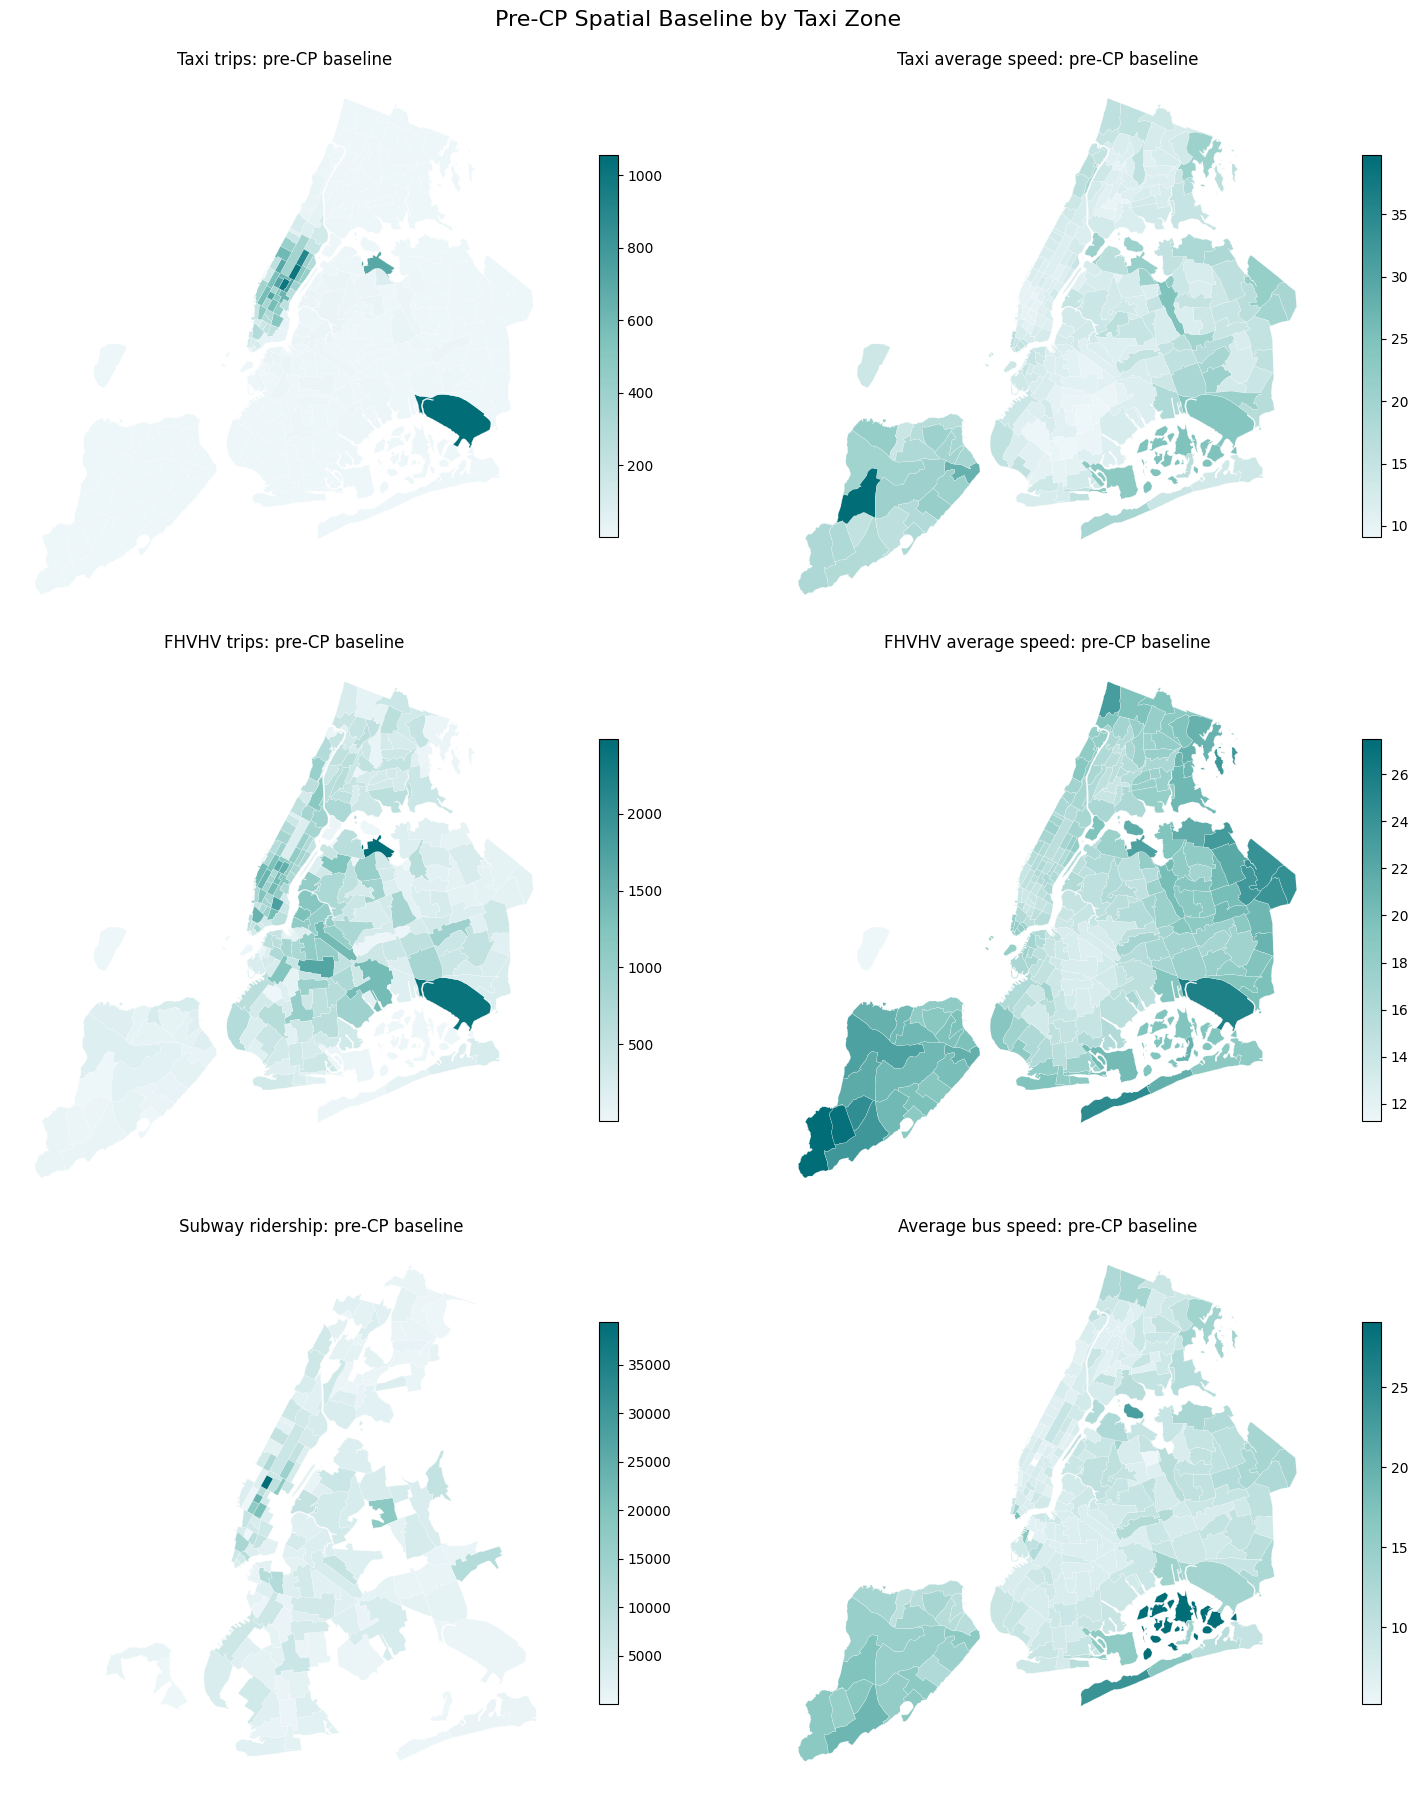

In [26]:
# ---------------------------------------------------------------------
# Map baseline pre-CP spatial activity patterns
# ---------------------------------------------------------------------

baseline_spatial_gdf = zone_spatial_period_gdf.loc[
    zone_spatial_period_gdf["analysis_period"] == "pre_cp"
].copy()

baseline_cmap = LinearSegmentedColormap.from_list(
    "brand_sequential",
    [
        BRAND_COLORS["ice"],
        BRAND_COLORS["seafoam"],
        BRAND_COLORS["dark_teal"],
    ],
)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for ax, metric in zip(axes, CORE_MOBILITY_METRICS):
    plot_gdf = baseline_spatial_gdf.loc[baseline_spatial_gdf[metric].notna()].copy()

    plot_gdf.plot(
        column=metric,
        cmap=baseline_cmap,
        linewidth=0.15,
        edgecolor="white",
        legend=True,
        legend_kwds={"shrink": 0.7},
        ax=ax,
        missing_kwds={"color": "#d9d9d9"},
    )

    ax.set_title(f"{METRIC_LABELS[metric]}: pre-CP baseline", fontsize=12)
    ax.set_axis_off()

fig.suptitle("Pre-CP Spatial Baseline by Taxi Zone", fontsize=16, y=0.995)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        EDA_OUTPUT_DIR / "pre_cp_spatial_baseline_maps.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. The pre\-CP baseline maps show that the six core metrics were never spatially uniform to begin with, which matters because any later change map has to be read against that uneven starting point\. Taxi and FHVHV trip activity are both heavily concentrated in the Manhattan core and at the airport\-oriented edge cases, while Subway ridership is even more tightly anchored to dense corridor zones in Manhattan and a smaller set of high\-transit outer\-borough locations\. The speed maps tell a different story: the fastest Taxi, FHVHV, and Bus zones tend to sit farther from the most congested central core, with slower values clustering more visibly in Manhattan and the denser inner\-city parts of Brooklyn and Queens\. So even before congestion pricing, demand and performance were already organized by a strong center\-versus\-periphery pattern, with the core dominating activity while outer zones more often dominate speed\.

### Map pre/post spatial change

Now we can ask the harder question: did the geography itself move after congestion pricing, or did the same places mostly stay on top? These change maps use zone\-level percent change from the pre\-CP average bucket value to the post\-CP average bucket value, which makes it easier to see relative shifts rather than just raw magnitude\.

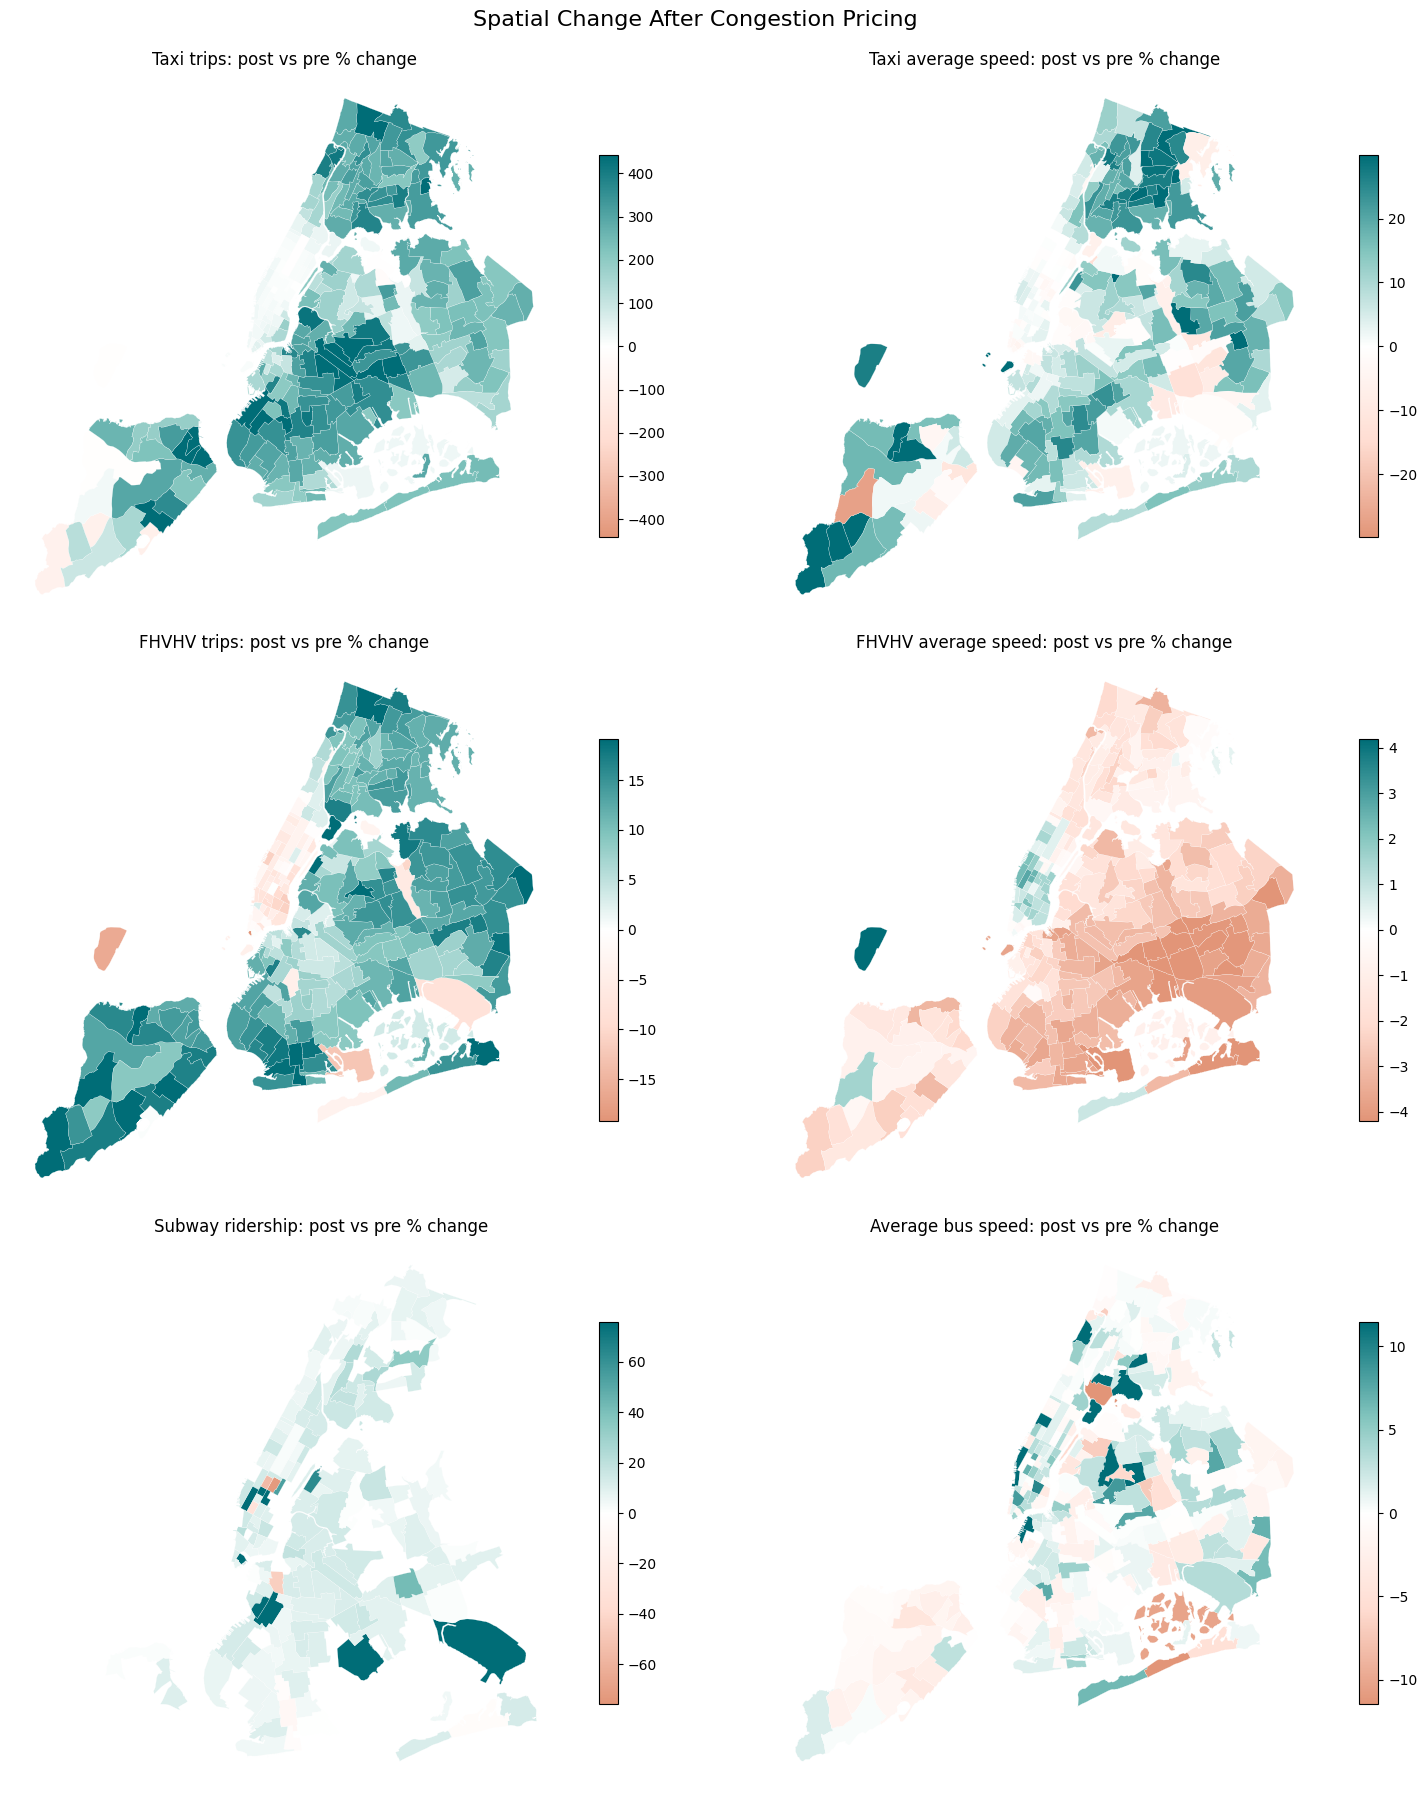

In [27]:
# ---------------------------------------------------------------------
# Build and map pre/post spatial change by Taxi Zone
# ---------------------------------------------------------------------

zone_spatial_change_frames = []

for metric in CORE_MOBILITY_METRICS:
    metric_change_df = (
        zone_spatial_period_summary_df[
            [spatial_join_key, "zone", "borough", "cbd_spatial_category", "analysis_period", metric]
        ]
        .pivot(
            index=[spatial_join_key, "zone", "borough", "cbd_spatial_category"],
            columns="analysis_period",
            values=metric,
        )
        .reset_index()
    )

    metric_change_df["metric"] = metric
    metric_change_df["metric_label"] = METRIC_LABELS[metric]
    metric_change_df["absolute_change"] = metric_change_df["post_cp"] - metric_change_df["pre_cp"]
    metric_change_df["pct_change"] = np.where(
        metric_change_df["pre_cp"].notna() & (metric_change_df["pre_cp"] != 0),
        ((metric_change_df["post_cp"] - metric_change_df["pre_cp"]) / metric_change_df["pre_cp"]) * 100,
        np.nan,
    )

    zone_spatial_change_frames.append(metric_change_df)

zone_spatial_change_df = pd.concat(zone_spatial_change_frames, ignore_index=True)

zone_spatial_change_gdf = zone_geometry_gdf.merge(
    zone_spatial_change_df,
    on=spatial_join_key,
    how="inner",
)

change_cmap = LinearSegmentedColormap.from_list(
    "brand_diverging_map",
    [
        BRAND_COLORS["terracotta"],
        BRAND_COLORS["pale_peach"],
        "#ffffff",
        BRAND_COLORS["seafoam"],
        BRAND_COLORS["dark_teal"],
    ],
)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for ax, metric in zip(axes, CORE_MOBILITY_METRICS):
    plot_gdf = zone_spatial_change_gdf.loc[
        (zone_spatial_change_gdf["metric"] == metric)
        & zone_spatial_change_gdf["pct_change"].notna()
    ].copy()

    vmax = np.nanpercentile(np.abs(plot_gdf["pct_change"]), 95)
    vmax = max(vmax, 1)

    plot_gdf.plot(
        column="pct_change",
        cmap=change_cmap,
        linewidth=0.15,
        edgecolor="white",
        legend=True,
        vmin=-vmax,
        vmax=vmax,
        legend_kwds={"shrink": 0.7},
        ax=ax,
        missing_kwds={"color": "#d9d9d9"},
    )

    ax.set_title(f"{METRIC_LABELS[metric]}: post vs pre % change", fontsize=12)
    ax.set_axis_off()

fig.suptitle("Spatial Change After Congestion Pricing", fontsize=16, y=0.995)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        EDA_OUTPUT_DIR / "post_vs_pre_spatial_change_maps.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. The change maps suggest that congestion pricing did not simply reinforce the pre\-existing spatial pattern in the same way for every modality\. Taxi trips rise across most of the city, which makes the Taxi demand lift look broad rather than narrowly confined to a handful of Manhattan zones, and Taxi speeds also improve in many areas even though the gains are more uneven and mixed with a few localized slowdowns\. FHVHV trips also trend positive in much of the city, but FHVHV average speed moves in the opposite direction, with widespread declines that are especially visible outside the Manhattan core, which makes FHVHV look much less like a clear system winner than Taxi\. Subway ridership changes appear more selective and corridor\-shaped rather than broadly citywide, while average bus speed shows a patchier, mixed pattern with improvements and declines coexisting across neighboring zones\. So the main spatial takeaway is that Taxi’s post\-CP shift looks both broad and favorable, whereas the other modalities show either weaker gains, more localized movement, or a tradeoff between activity and speed\.

We only want to highlight movers that were already materially active before congestion pricing\. This screen removes low\-baseline edge cases so the zone\-level leaderboard reflects meaningful shifts rather than tiny starting values exploding into extreme percentages\.

In [28]:
# ---------------------------------------------------------------------
# Summarize the strongest meaningful zone-level spatial movers
# ---------------------------------------------------------------------

meaningful_baseline_thresholds = {
    "taxi_trip_count": 25,
    "taxi_avg_trip_speed": 100,
    "fhvhv_trip_count": 100,
    "fhvhv_avg_trip_speed": 500,
    "subway_ridership": 500,
    "avg_bus_speed": 25,
}

supporting_volume_lookup = {
    "taxi_trip_count": "pre_cp",
    "taxi_avg_trip_speed": "taxi_trip_count",
    "fhvhv_trip_count": "pre_cp",
    "fhvhv_avg_trip_speed": "fhvhv_trip_count",
    "subway_ridership": "pre_cp",
    "avg_bus_speed": "bus_trip_count",
}

zone_metric_support_df = (
    mobility_panel_df.groupby(spatial_join_key, observed=True)[
        ["taxi_trip_count", "fhvhv_trip_count", "bus_trip_count"]
    ]
    .mean()
    .reset_index()
    .rename(
        columns={
            "taxi_trip_count": "support_taxi_trip_count",
            "fhvhv_trip_count": "support_fhvhv_trip_count",
            "bus_trip_count": "support_bus_trip_count",
        }
    )
)

meaningful_spatial_change_df = zone_spatial_change_gdf.merge(
    zone_metric_support_df,
    on=spatial_join_key,
    how="left",
)

spatial_mover_records = []

for metric in CORE_MOBILITY_METRICS:
    metric_df = meaningful_spatial_change_df.loc[
        meaningful_spatial_change_df["metric"] == metric
    ].copy()

    zone_col = "zone_x" if "zone_x" in metric_df.columns else "zone"
    borough_col = "borough_x" if "borough_x" in metric_df.columns else "borough"

    support_col_lookup = {
        "taxi_avg_trip_speed": "support_taxi_trip_count",
        "fhvhv_avg_trip_speed": "support_fhvhv_trip_count",
        "avg_bus_speed": "support_bus_trip_count",
    }

    if metric in support_col_lookup:
        eligible_mask = metric_df[support_col_lookup[metric]] >= meaningful_baseline_thresholds[metric]
    else:
        eligible_mask = metric_df["pre_cp"] >= meaningful_baseline_thresholds[metric]

    eligible_df = metric_df.loc[
        eligible_mask & metric_df["pct_change"].notna()
    ].copy()

    if eligible_df.empty:
        spatial_mover_records.append(
            {
                "metric": metric,
                "metric_label": METRIC_LABELS[metric],
                "largest_mover_zone": np.nan,
                "borough": np.nan,
                "pre_cp_value": np.nan,
                "post_cp_value": np.nan,
                "absolute_change": np.nan,
                "pct_change": np.nan,
                "eligibility_threshold": meaningful_baseline_thresholds[metric],
                "eligible_zone_count": 0,
            }
        )
        continue

    eligible_df["abs_pct_change"] = eligible_df["pct_change"].abs()
    top_row = eligible_df.loc[eligible_df["abs_pct_change"].idxmax()]

    spatial_mover_records.append(
        {
            "metric": metric,
            "metric_label": METRIC_LABELS[metric],
            "largest_mover_zone": top_row[zone_col],
            "borough": top_row[borough_col],
            "pre_cp_value": top_row["pre_cp"],
            "post_cp_value": top_row["post_cp"],
            "absolute_change": top_row["absolute_change"],
            "pct_change": top_row["pct_change"],
            "eligibility_threshold": meaningful_baseline_thresholds[metric],
            "eligible_zone_count": len(eligible_df),
        }
    )

meaningful_spatial_change_summary_df = (
    pd.DataFrame(spatial_mover_records)
    .round(3)
)

display(meaningful_spatial_change_summary_df)

,metric,metric_label,largest_mover_zone,borough,pre_cp_value,post_cp_value,absolute_change,pct_change,eligibility_threshold,eligible_zone_count
0,taxi_trip_count,Taxi trips,Alphabet City,Manhattan,32.012,89.817,57.805,180.570,25,59
1,taxi_avg_trip_speed,Taxi average speed,East Harlem North,Manhattan,11.537,12.568,1.031,8.932,100,48
2,fhvhv_trip_count,FHVHV trips,Queensbridge/Ravenswood,Queens,184.002,229.091,45.088,24.504,100,218
3,fhvhv_avg_trip_speed,FHVHV average speed,South Ozone Park,Queens,17.510,16.445,-1.065,-6.082,500,103
4,subway_ridership,Subway ridership,Gowanus,Brooklyn,543.553,2332.584,1789.031,329.137,500,142
5,avg_bus_speed,Average bus speed,Columbia Street,Brooklyn,16.390,23.552,7.162,43.699,25,252


Findings\. After thresholding out the low\-baseline edge cases, this mover table becomes much more credible and useful\. The biggest meaningful Taxi gain shows up in Alphabet City, while FHVHV trip growth is strongest in Queensbridge/Ravenswood, which suggests that the post\-CP demand response was not confined to a single Manhattan\-core pattern\. The speed results are more mixed: Taxi speed improvement in East Harlem North is modest but believable, while FHVHV speed in South Ozone Park actually declines, which fits the broader map story that FHVHV did not enjoy the same clean performance lift as Taxi\. Subway ridership in Gowanus and bus speed in Columbia Street still stand out sharply, so those specific cases are worth treating as notable local movers rather than generic citywide evidence\. Overall, this version of the table works much better as a calibrated spotlight on meaningful spatial movers instead of a distorted percent\-change leaderboard\.

The maps show where movement is happening, but a ranked view makes the strongest meaningful movers easier to compare directly\. This keeps the thresholded mover logic while making the spatial\-change story more legible\.

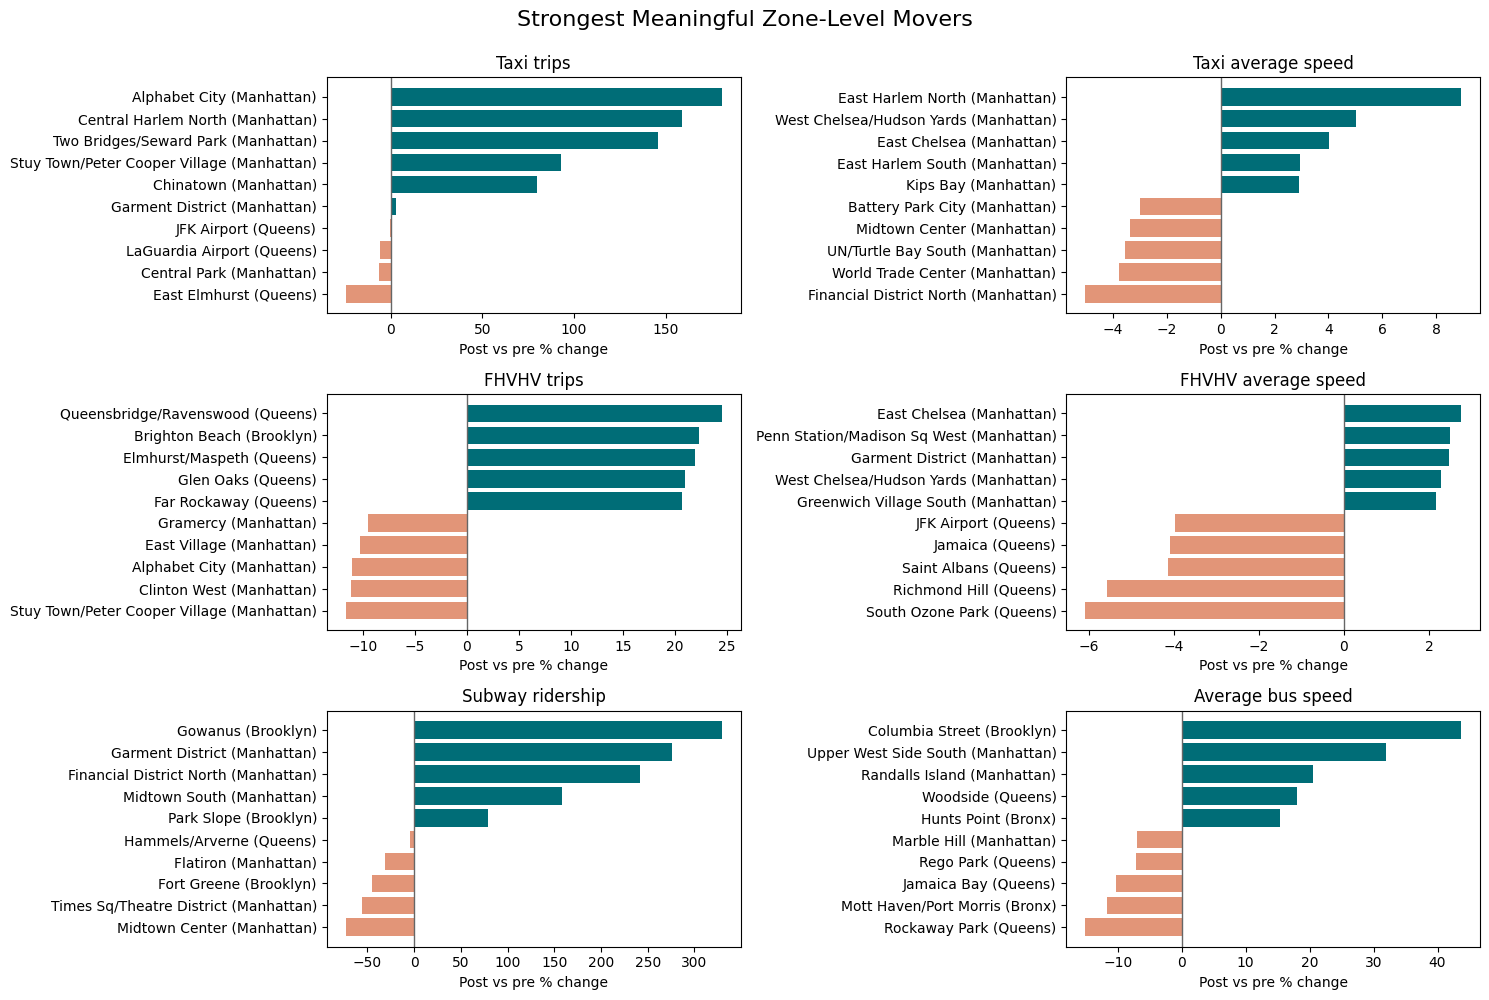

In [29]:
# ---------------------------------------------------------------------
# Visualize the strongest meaningful zone-level movers
# ---------------------------------------------------------------------

ranked_spatial_movers_df = meaningful_spatial_change_df.copy()

zone_col = "zone_x" if "zone_x" in ranked_spatial_movers_df.columns else "zone"
borough_col = "borough_x" if "borough_x" in ranked_spatial_movers_df.columns else "borough"

support_col_lookup = {
    "taxi_avg_trip_speed": "support_taxi_trip_count",
    "fhvhv_avg_trip_speed": "support_fhvhv_trip_count",
    "avg_bus_speed": "support_bus_trip_count",
}

eligible_frames = []

for metric in CORE_MOBILITY_METRICS:
    metric_df = ranked_spatial_movers_df.loc[
        ranked_spatial_movers_df["metric"] == metric
    ].copy()

    if metric in support_col_lookup:
        eligible_mask = metric_df[support_col_lookup[metric]] >= meaningful_baseline_thresholds[metric]
    else:
        eligible_mask = metric_df["pre_cp"] >= meaningful_baseline_thresholds[metric]

    metric_df = metric_df.loc[eligible_mask & metric_df["pct_change"].notna()].copy()
    metric_df["zone_display"] = metric_df[zone_col] + " (" + metric_df[borough_col] + ")"
    metric_df["metric_label"] = METRIC_LABELS[metric]
    eligible_frames.append(metric_df)

ranked_spatial_movers_df = pd.concat(eligible_frames, ignore_index=True)

top_spatial_movers_plot_df = (
    ranked_spatial_movers_df.groupby("metric", observed=True, group_keys=False)
    .apply(lambda df: pd.concat([df.nlargest(5, "pct_change"), df.nsmallest(5, "pct_change")]))
    .drop_duplicates(subset=["metric", spatial_join_key])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, metric in zip(axes, CORE_MOBILITY_METRICS):
    metric_df = top_spatial_movers_plot_df.loc[
        top_spatial_movers_plot_df["metric"] == metric
    ].sort_values("pct_change")

    colors = [
        BRAND_COLORS["dark_teal"] if x > 0 else BRAND_COLORS["terracotta"]
        for x in metric_df["pct_change"]
    ]

    ax.barh(metric_df["zone_display"], metric_df["pct_change"], color=colors)
    ax.axvline(0, color="#666666", linewidth=1)
    ax.set_title(METRIC_LABELS[metric], fontsize=12)
    ax.set_xlabel("Post vs pre % change")
    ax.set_ylabel("")

fig.suptitle("Strongest Meaningful Zone-Level Movers", fontsize=16, y=0.995)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        EDA_OUTPUT_DIR / "strongest_meaningful_spatial_movers.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. This ranked view makes the spatial change story much easier to read than the maps alone\. Taxi trips show the strongest upside concentration in Manhattan neighborhoods like Alphabet City, Central Harlem North, and Two Bridges/Seward Park, while the few meaningful negative movers are much smaller in magnitude, which reinforces the sense of a broadly favorable Taxi demand shift\. FHVHV trips also have clear positive movers, but the gains are more modest and more mixed with meaningful Manhattan declines\. On the performance side, Taxi average speed improves most in Manhattan zones like East Harlem North and the Chelsea/Hudson Yards area, while the largest slowdowns cluster in the Manhattan core and lower Manhattan business districts\. FHVHV average speed tells a more negative outer\-borough story, with the largest declines concentrated in Queens\. Subway ridership has the most dramatic upside movers of all, led by Gowanus and several Manhattan business\-core zones, but it also shows meaningful negative movers in Midtown and Times Square\. Average bus speed is the most mixed and localized, with a few very large positive movers like Columbia Street and Upper West Side South alongside several outer\-borough declines\. Taken together, the chart shows that post\-CP change was not just about broad citywide averages: each modality had its own distinct geography of winners and losers\.

### Compare Manhattan/CBD\-oriented areas versus the rest of the city \(by Policy\-Geo\)

Let’s finish with a simpler policy\-geography cut\. Instead of inspecting every zone individually, we’ll collapse the panel into the four cbd\_spatial\_category groups and ask whether the pre/post change looks meaningfully different in CBD\-oriented areas than in adjacent or non\-CBD parts of the city\.

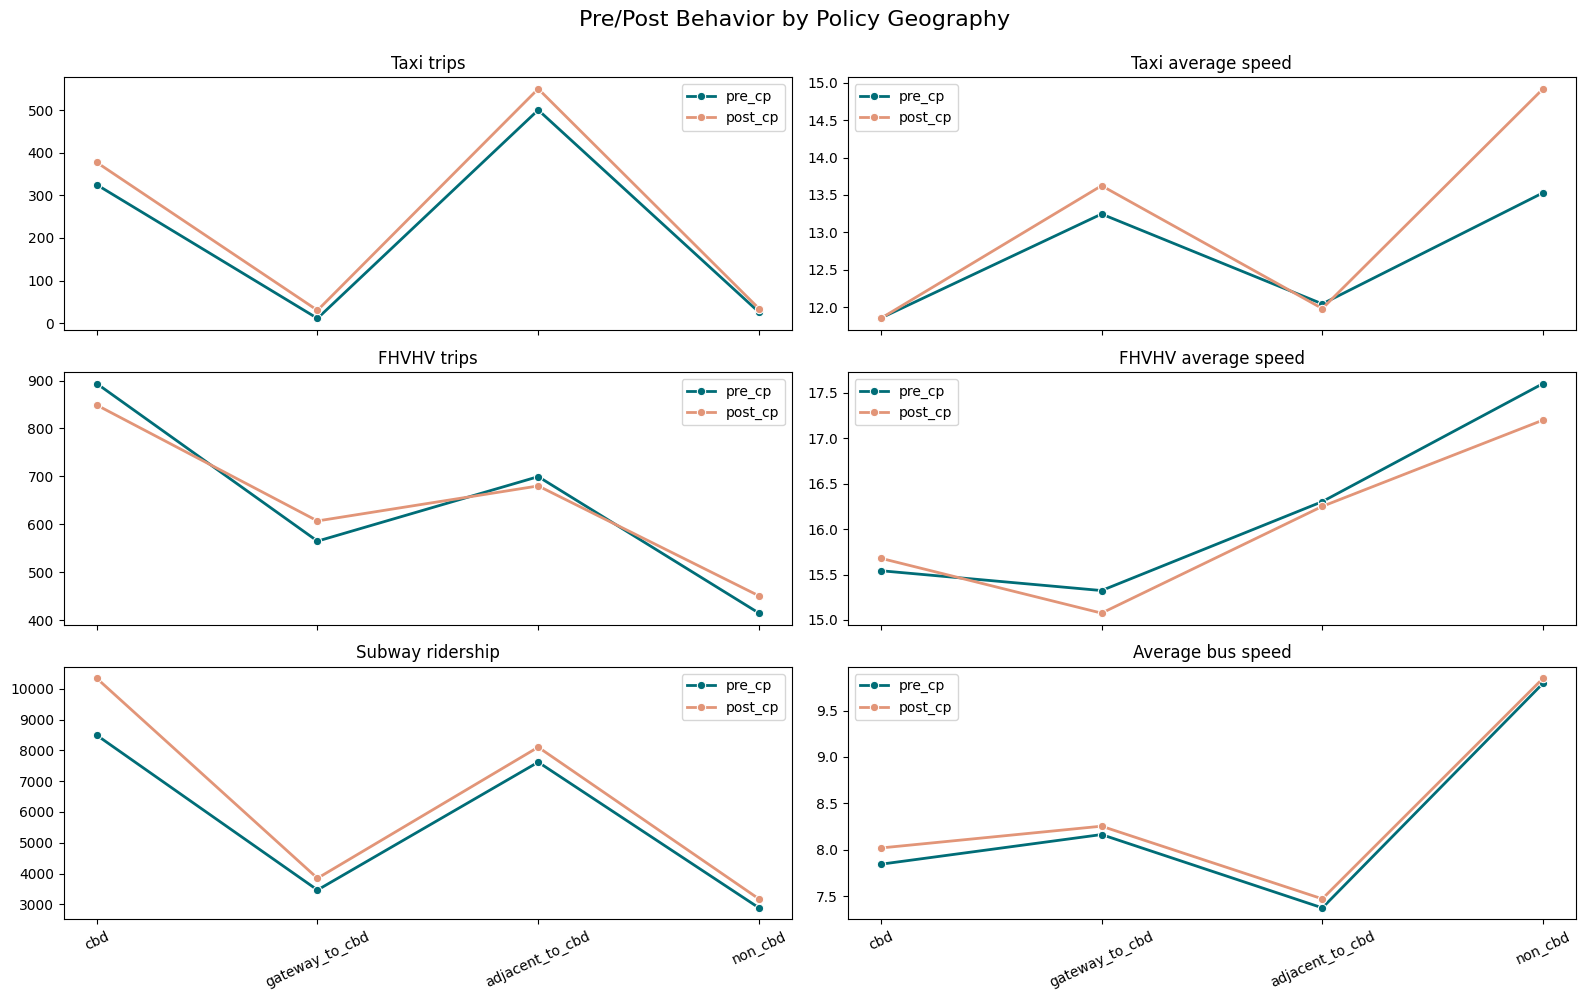

In [30]:
# ---------------------------------------------------------------------
# Compare pre/post behavior by policy geography
# ---------------------------------------------------------------------

policy_geo_period_summary_df = (
    mobility_panel_df.groupby(
        ["cbd_spatial_category", "analysis_period"],
        observed=True,
    )[CORE_MOBILITY_METRICS]
    .mean()
    .reset_index()
)

policy_geo_period_long_df = (
    policy_geo_period_summary_df.melt(
        id_vars=["cbd_spatial_category", "analysis_period"],
        value_vars=CORE_MOBILITY_METRICS,
        var_name="metric",
        value_name="metric_value",
    )
    .assign(metric_label=lambda df: df["metric"].map(METRIC_LABELS))
)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, CORE_MOBILITY_METRICS):
    metric_df = policy_geo_period_long_df.loc[
        policy_geo_period_long_df["metric"] == metric
    ].copy()

    sns.lineplot(
        data=metric_df,
        x="cbd_spatial_category",
        y="metric_value",
        hue="analysis_period",
        palette={
            "pre_cp": BRAND_COLORS["dark_teal"],
            "post_cp": BRAND_COLORS["terracotta"],
        },
        marker="o",
        linewidth=2,
        ax=ax,
    )

    ax.set_title(METRIC_LABELS[metric], fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.legend_.set_title("")

for ax in axes[len(CORE_MOBILITY_METRICS):]:
    ax.axis("off")

fig.suptitle("Pre/Post Behavior by Policy Geography", fontsize=16, y=0.995)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        EDA_OUTPUT_DIR / "policy_geo_pre_post_profiles.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. The policy\-geography view helps clarify that the post\-CP shifts were not spatially neutral, but they also were not as simple as “everything happened in the CBD\.” Taxi trips rise everywhere, but the biggest relative gains show up in gateway and non\-CBD zones, which suggests that the Taxi response spread well beyond the pricing core itself\. Subway ridership also increases across all four geography groups, with the strongest lift in the CBD and a still\-meaningful rise in gateway and non\-CBD areas, which fits a broader transit\-demand response anchored in the core but not limited to it\. FHVHV is more mixed: trips fall in the CBD and adjacent\-to\-CBD zones but rise in gateway and non\-CBD areas, while FHVHV speed softens outside the core\. Bus speed improves a bit everywhere, but only modestly\. So the policy\-geography story is not “CBD wins, everyone else loses\.” It is closer to a rebalancing pattern where Taxi and Subway gains extend outward, while FHVHV weakens in the core and shifts relatively more toward outer geography\.

This last table makes the policy\-geography comparison easier to read without squinting at every panel\. It shows the pre/post percent change for each metric within each policy\-geography group so we can see where the regime shift looks strongest or weakest\.

In [31]:
# ---------------------------------------------------------------------
# Summarize pre/post percent change by policy geography
# ---------------------------------------------------------------------

policy_geo_change_frames = []

for metric in CORE_MOBILITY_METRICS:
    metric_df = (
        policy_geo_period_summary_df[
            ["cbd_spatial_category", "analysis_period", metric]
        ]
        .pivot(
            index="cbd_spatial_category",
            columns="analysis_period",
            values=metric,
        )
        .reset_index()
    )

    metric_df["metric"] = metric
    metric_df["metric_label"] = METRIC_LABELS[metric]
    metric_df["pct_change"] = np.where(
        metric_df["pre_cp"].notna() & (metric_df["pre_cp"] != 0),
        ((metric_df["post_cp"] - metric_df["pre_cp"]) / metric_df["pre_cp"]) * 100,
        np.nan,
    )

    policy_geo_change_frames.append(metric_df)

policy_geo_change_summary_df = (
    pd.concat(policy_geo_change_frames, ignore_index=True)
    .round(3)
    .sort_values(["metric_label", "cbd_spatial_category"])
    .reset_index(drop=True)
)

display(
    policy_geo_change_summary_df[
        ["metric_label", "cbd_spatial_category", "pre_cp", "post_cp", "pct_change"]
    ]
)

analysis_period,metric_label,cbd_spatial_category,pre_cp,post_cp,pct_change
0,Average bus speed,cbd,7.844,8.019,2.231
1,Average bus speed,gateway_to_cbd,8.164,8.254,1.104
2,Average bus speed,adjacent_to_cbd,7.374,7.471,1.315
3,Average bus speed,non_cbd,9.794,9.848,0.550
4,FHVHV average speed,cbd,15.542,15.679,0.882
5,FHVHV average speed,gateway_to_cbd,15.324,15.075,-1.623
6,FHVHV average speed,adjacent_to_cbd,16.303,16.251,-0.321
7,FHVHV average speed,non_cbd,17.604,17.201,-2.286
8,FHVHV trips,cbd,893.710,848.779,-5.027
9,FHVHV trips,gateway_to_cbd,564.790,606.935,7.462


Findings\. The percent\-change table makes that pattern more explicit\. Taxi is the clearest example of outward spillover: CBD trips rise about 16\.1%, but gateway zones jump about 169\.5% and non\-CBD zones rise about 32\.2%, which strongly suggests the Taxi response was not confined to the pricing zone itself\. Subway ridership increases everywhere too, led by a 21\.8% gain in the CBD and smaller but still solid gains in the other three groups\. FHVHV moves in the opposite direction in the core, with trips down about 5\.0% in the CBD and 2\.8% in adjacent zones, but up 7\.5% in gateway zones and 8\.7% in non\-CBD zones\. On the performance side, Taxi speed is basically flat in the CBD but improves most strongly in non\-CBD zones, while FHVHV speed declines outside the CBD and Bus speed edges up a little across all groups\. Taken together, the table points to a post\-CP geography shift where Taxi and Subway strengthen broadly, but FHVHV looks increasingly pushed away from the core and less performance\-favorable outside it\.

### Section Summary

At the spatial level, the post\-congestion\-pricing story is more nuanced than the citywide averages alone suggest\. The baseline maps showed that demand was already concentrated in the Manhattan core and a smaller set of airport\- and corridor\-linked zones, while higher speeds tended to sit farther from the densest central areas\. The change maps then made clear that Taxi experienced the broadest and most favorable spatial shift, with demand gains showing up across much of the city and speed improvements appearing in many zones as well\. Subway also strengthened, but in a more corridor\-shaped and selectively concentrated way\. FHVHV looked more mixed: trips rose in many places, but speeds softened across large parts of the map, especially outside the core\. The policy\-geography view sharpened that story further by showing that post\-CP gains were not confined to the CBD\. Taxi and Subway both grew across all geography groups, while FHVHV weakened in the core and shifted relatively more toward gateway and non\-CBD areas\. Taken together, this chapter suggests that congestion pricing did not just change overall mobility levels; it also reshaped where different mobility responses were strongest, with Taxi showing the clearest broad\-based spatial lift\.

## 1\.4\.1\.4 Zone\-level distinctiveness and aggregation loss

This section moves from broad spatial patterns to a small set of concrete Taxi Zones\. The goal is to see whether a few statistically chosen zones behave differently enough from the citywide and borough\-level summaries to matter, and whether those local differences help explain why later app views and downstream modeling should keep the Taxi Zone grain intact\.

### Select high\-interest Taxi Zones for closer review

Let’s choose a small set of zones by rule instead of by vibe\. We want a mix of high\-activity zones, strong pre/post movers, a temporally distinctive zone, and at least one outer\-borough contrast so we can test whether aggregation is hiding meaningful local structure\.

In [32]:
# ---------------------------------------------------------------------
# Select 8 high-interest Taxi Zones for closer review
# ---------------------------------------------------------------------

EXCLUDED_ZONE_PATTERNS = [
    "Airport",
    "Park",
    "Cemetery",
    "Island",
    "Jamaica Bay",
    "Freshkills",
    "Marine",
    "Terminal",
]

def is_special_purpose_zone(zone_name: str) -> bool:
    if pd.isna(zone_name):
        return True
    return any(pattern.lower() in zone_name.lower() for pattern in EXCLUDED_ZONE_PATTERNS)

zone_base_df = (
    mobility_panel_df.groupby(
        ["taxi_zone_id", "zone", "borough", "cbd_spatial_category"],
        observed=True,
    )[CORE_MOBILITY_METRICS + ["bus_trip_count"]]
    .mean()
    .reset_index()
)

zone_base_df = zone_base_df.loc[
    ~zone_base_df["zone"].apply(is_special_purpose_zone)
].copy()

zone_change_frames = []

for metric in CORE_MOBILITY_METRICS:
    metric_change_df = (
        mobility_panel_df.groupby(
            ["taxi_zone_id", "zone", "borough", "cbd_spatial_category", "analysis_period"],
            observed=True,
        )[metric]
        .mean()
        .reset_index()
        .pivot(
            index=["taxi_zone_id", "zone", "borough", "cbd_spatial_category"],
            columns="analysis_period",
            values=metric,
        )
        .reset_index()
    )

    metric_change_df["metric"] = metric
    metric_change_df["pct_change"] = np.where(
        metric_change_df["pre_cp"].notna() & (metric_change_df["pre_cp"] != 0),
        ((metric_change_df["post_cp"] - metric_change_df["pre_cp"]) / metric_change_df["pre_cp"]) * 100,
        np.nan,
    )

    zone_change_frames.append(metric_change_df)

zone_change_df = pd.concat(zone_change_frames, ignore_index=True)
zone_change_df = zone_change_df.loc[
    ~zone_change_df["zone"].apply(is_special_purpose_zone)
].copy()

# Taxi temporal distinctiveness vs citywide profile
citywide_taxi_bucket_df = (
    mobility_panel_df.groupby("temporal_bucket", observed=True)["taxi_trip_count"]
    .mean()
    .reset_index()
)
citywide_taxi_bucket_df["citywide_share"] = (
    citywide_taxi_bucket_df["taxi_trip_count"] /
    citywide_taxi_bucket_df["taxi_trip_count"].sum()
)

zone_taxi_bucket_df = (
    mobility_panel_df.groupby(
        ["taxi_zone_id", "zone", "borough", "cbd_spatial_category", "temporal_bucket"],
        observed=True,
    )["taxi_trip_count"]
    .mean()
    .reset_index()
)

zone_taxi_bucket_df = zone_taxi_bucket_df.loc[
    ~zone_taxi_bucket_df["zone"].apply(is_special_purpose_zone)
].copy()

zone_taxi_bucket_df["zone_share"] = (
    zone_taxi_bucket_df.groupby("taxi_zone_id", observed=True)["taxi_trip_count"]
    .transform(lambda s: s / s.sum())
)

zone_temporal_distinctiveness_df = (
    zone_taxi_bucket_df.merge(
        citywide_taxi_bucket_df[["temporal_bucket", "citywide_share"]],
        on="temporal_bucket",
        how="left",
    )
)
zone_temporal_distinctiveness_df["share_gap"] = (
    zone_temporal_distinctiveness_df["zone_share"] -
    zone_temporal_distinctiveness_df["citywide_share"]
).abs()

zone_temporal_distinctiveness_df = (
    zone_temporal_distinctiveness_df.groupby(
        ["taxi_zone_id", "zone", "borough", "cbd_spatial_category"],
        observed=True,
    )["share_gap"]
    .sum()
    .reset_index(name="temporal_distinctiveness")
    .sort_values("temporal_distinctiveness", ascending=False)
)

selected_zone_records = []
selected_zone_ids = set()

def add_zone(candidate_df, reason_label, borough_rule=None, category_rule=None):
    working_df = candidate_df.copy()
    if borough_rule is not None:
        working_df = working_df.loc[working_df["borough"].isin(borough_rule)]
    if category_rule is not None:
        working_df = working_df.loc[working_df["cbd_spatial_category"].isin(category_rule)]
    working_df = working_df.loc[~working_df["taxi_zone_id"].isin(selected_zone_ids)]
    if working_df.empty:
        return
    top_row = working_df.iloc[0]
    selected_zone_ids.add(top_row["taxi_zone_id"])
    selected_zone_records.append(
        {
            "selection_reason": reason_label,
            "taxi_zone_id": top_row["taxi_zone_id"],
            "zone": top_row["zone"],
            "borough": top_row["borough"],
            "cbd_spatial_category": top_row["cbd_spatial_category"],
        }
    )

# 1. Manhattan taxi anchor
add_zone(
    zone_base_df.sort_values("taxi_trip_count", ascending=False),
    "manhattan_taxi_anchor",
    borough_rule=["Manhattan"],
)

# 2. Manhattan subway anchor
add_zone(
    zone_base_df.sort_values("subway_ridership", ascending=False),
    "manhattan_subway_anchor",
    borough_rule=["Manhattan"],
)

# 3. Outer-borough taxi anchor
add_zone(
    zone_base_df.sort_values("taxi_trip_count", ascending=False),
    "outer_borough_taxi_anchor",
    borough_rule=["Brooklyn", "Queens", "Bronx", "Staten Island"],
)

# 4. Outer-borough fhvhv anchor
add_zone(
    zone_base_df.sort_values("fhvhv_trip_count", ascending=False),
    "outer_borough_fhvhv_anchor",
    borough_rule=["Brooklyn", "Queens", "Bronx", "Staten Island"],
)

# 5. Strongest positive pre/post mover across core demand metrics
positive_change_df = (
    zone_change_df.loc[
        zone_change_df["metric"].isin(["taxi_trip_count", "fhvhv_trip_count", "subway_ridership"])
    ]
    .groupby(["taxi_zone_id", "zone", "borough", "cbd_spatial_category"], observed=True)["pct_change"]
    .mean()
    .reset_index(name="mean_pct_change")
    .sort_values("mean_pct_change", ascending=False)
)
add_zone(positive_change_df, "strongest_positive_shift")

# 6. Strongest negative pre/post mover across core demand metrics
negative_change_df = positive_change_df.sort_values("mean_pct_change", ascending=True)
add_zone(negative_change_df, "strongest_negative_shift")

# 7. Most temporally distinctive zone
add_zone(zone_temporal_distinctiveness_df, "most_temporally_distinctive")

# 8. Outer-borough contrast with balanced multimodal activity
outer_borough_balance_df = zone_base_df.loc[
    zone_base_df["borough"].isin(["Brooklyn", "Queens", "Bronx", "Staten Island"])
].copy()

outer_borough_balance_df["balance_score"] = (
    outer_borough_balance_df["taxi_trip_count"].rank(pct=True) +
    outer_borough_balance_df["fhvhv_trip_count"].rank(pct=True) +
    outer_borough_balance_df["subway_ridership"].rank(pct=True)
) / 3

outer_borough_balance_df = outer_borough_balance_df.sort_values(
    "balance_score", ascending=False
)

add_zone(outer_borough_balance_df, "outer_borough_balanced_contrast")

selected_zones_df = pd.DataFrame(selected_zone_records)

display(selected_zones_df)

,selection_reason,taxi_zone_id,zone,borough,cbd_spatial_category
0,manhattan_taxi_anchor,237,Upper East Side South,Manhattan,adjacent_to_cbd
1,manhattan_subway_anchor,230,Times Sq/Theatre District,Manhattan,cbd
2,outer_borough_taxi_anchor,70,East Elmhurst,Queens,non_cbd
3,outer_borough_fhvhv_anchor,61,Crown Heights North,Brooklyn,non_cbd
4,strongest_positive_shift,68,East Chelsea,Manhattan,cbd
5,strongest_negative_shift,5,Arden Heights,Staten Island,non_cbd
6,most_temporally_distinctive,157,Maspeth,Queens,non_cbd
7,outer_borough_balanced_contrast,7,Astoria,Queens,non_cbd


Findings\. The selected zones give us a nicely varied set of local contexts to compare against the broader city patterns\. Two Manhattan anchors stand out in different ways, with Upper East Side South representing a strong Taxi\-oriented core\-adjacent zone and Times Square/Theatre District capturing a transit\-heavy CBD setting\. The outer\-borough set adds a different mix of neighborhood types, including East Elmhurst, Crown Heights North, Maspeth, and Astoria, while East Chelsea and Arden Heights give us clear positive\- and negative\-shift contrasts\. Taken together, this set looks diverse enough to test whether zone\-level temporal behavior really departs from citywide and borough\-level summaries in a way that matters\.

### Compare selected\-zone temporal behavior against citywide patterns

Let’s compare the selected zones against the citywide baseline on temporal shape, not just raw level\. To keep the comparison readable, we’ll index each temporal\-bucket profile to its own mean so we can see whether a zone’s within\-day rhythm is unusually front\-loaded, peak\-heavy, or off\-pattern relative to the city\.

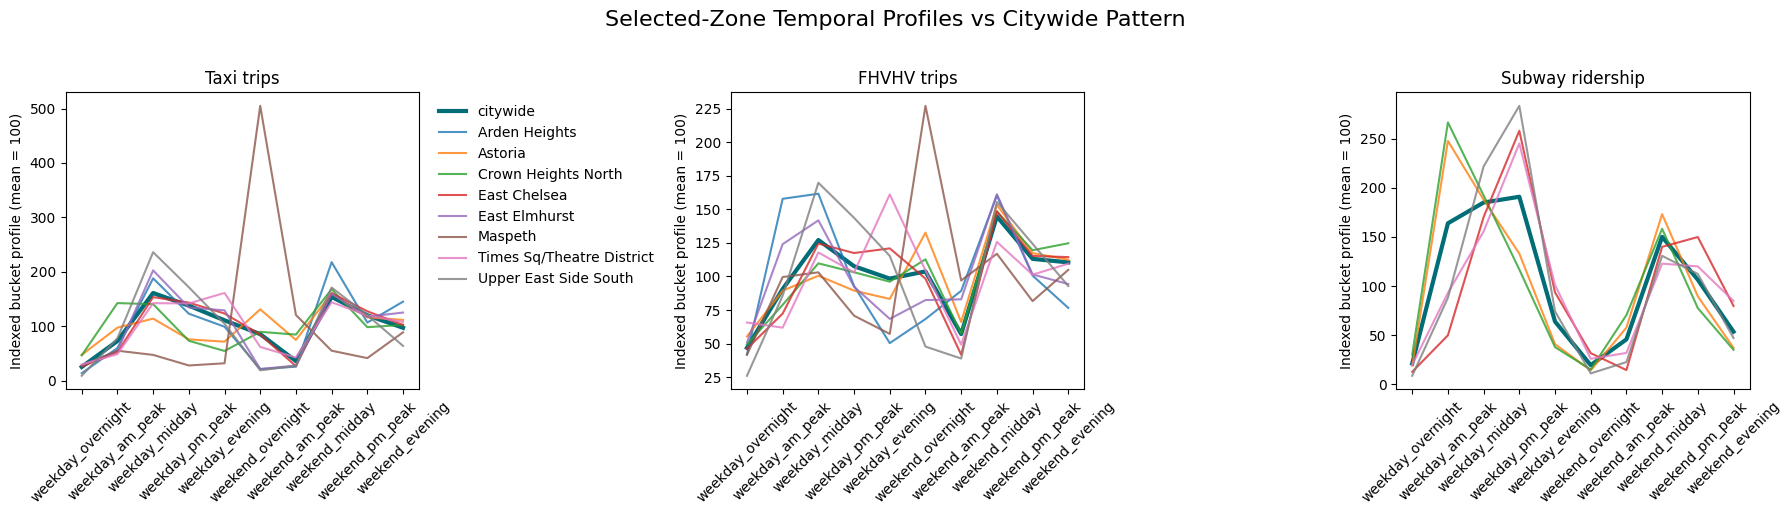

In [33]:
# ---------------------------------------------------------------------
# Compare selected-zone temporal behavior against the citywide pattern
# ---------------------------------------------------------------------

zone_citywide_profile_metrics = [
    "taxi_trip_count",
    "fhvhv_trip_count",
    "subway_ridership",
]

selected_zone_panel_df = mobility_panel_df.merge(
    selected_zones_df[["taxi_zone_id", "selection_reason"]],
    on="taxi_zone_id",
    how="inner",
)

selected_zone_bucket_profile_df = (
    selected_zone_panel_df.groupby(
        ["taxi_zone_id", "zone", "selection_reason", "temporal_bucket", "temporal_bucket_order"],
        observed=True,
    )[zone_citywide_profile_metrics]
    .mean()
    .reset_index()
)

selected_zone_bucket_profile_long_df = selected_zone_bucket_profile_df.melt(
    id_vars=["taxi_zone_id", "zone", "selection_reason", "temporal_bucket", "temporal_bucket_order"],
    value_vars=zone_citywide_profile_metrics,
    var_name="metric",
    value_name="metric_value",
)

selected_zone_bucket_profile_long_df["profile_index"] = (
    selected_zone_bucket_profile_long_df.groupby(["taxi_zone_id", "metric"], observed=True)["metric_value"]
    .transform(lambda s: (s / s.mean()) * 100)
)

citywide_bucket_profile_compare_df = (
    mobility_panel_df.groupby(
        ["temporal_bucket", "temporal_bucket_order"],
        observed=True,
    )[zone_citywide_profile_metrics]
    .mean()
    .reset_index()
    .melt(
        id_vars=["temporal_bucket", "temporal_bucket_order"],
        value_vars=zone_citywide_profile_metrics,
        var_name="metric",
        value_name="metric_value",
    )
)

citywide_bucket_profile_compare_df["profile_index"] = (
    citywide_bucket_profile_compare_df.groupby("metric", observed=True)["metric_value"]
    .transform(lambda s: (s / s.mean()) * 100)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for ax, metric in zip(axes, zone_citywide_profile_metrics):
    citywide_metric_df = citywide_bucket_profile_compare_df.loc[
        citywide_bucket_profile_compare_df["metric"] == metric
    ].copy()

    ax.plot(
        citywide_metric_df["temporal_bucket"],
        citywide_metric_df["profile_index"],
        color=BRAND_COLORS["dark_teal"],
        linewidth=3,
        label="citywide",
    )

    metric_df = selected_zone_bucket_profile_long_df.loc[
        selected_zone_bucket_profile_long_df["metric"] == metric
    ].copy()

    for zone_name, zone_df in metric_df.groupby("zone", observed=True):
        ax.plot(
            zone_df["temporal_bucket"],
            zone_df["profile_index"],
            linewidth=1.5,
            alpha=0.8,
            label=zone_name,
        )

    ax.set_title(METRIC_LABELS[metric], fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Indexed bucket profile (mean = 100)")
    ax.tick_params(axis="x", rotation=45)

axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
fig.suptitle("Selected-Zone Temporal Profiles vs Citywide Pattern", fontsize=16, y=1.02)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        EDA_OUTPUT_DIR / "selected_zone_vs_citywide_profiles.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. The selected\-zone profiles make it very clear that citywide averages are smoothing over meaningful local variation\. Even after indexing each series to its own mean, the zones do not simply trace the citywide line with small noise around it\. Taxi is the clearest example: several zones show much sharper bucket\-level peaks than the citywide pattern, and one zone in particular has an extremely concentrated spike that would be almost invisible in a broad aggregate\. FHVHV profiles also vary substantially across zones, with some places much more midday\- or peak\-oriented than the city as a whole\. Subway ridership shows the strongest common structure overall, but even there the relative intensity and timing of the AM and PM peaks differ meaningfully from zone to zone\. So the main takeaway is that broad summaries preserve the rough shape of the day, but they absolutely flatten the magnitude and distinctiveness of local temporal behavior\.

A quick table makes the profile divergence more explicit\. This shows which selected zones depart most strongly from the citywide temporal shape for Taxi, FHVHV, and Subway\.

In [34]:
# ---------------------------------------------------------------------
# Summarize temporal-profile divergence from the citywide baseline
# ---------------------------------------------------------------------

zone_profile_divergence_df = selected_zone_bucket_profile_long_df.merge(
    citywide_bucket_profile_compare_df[
        ["temporal_bucket", "metric", "profile_index"]
    ].rename(columns={"profile_index": "citywide_profile_index"}),
    on=["temporal_bucket", "metric"],
    how="left",
)

zone_profile_divergence_df["abs_profile_gap"] = (
    zone_profile_divergence_df["profile_index"] -
    zone_profile_divergence_df["citywide_profile_index"]
).abs()

zone_profile_divergence_summary_df = (
    zone_profile_divergence_df.groupby(
        ["zone", "selection_reason", "metric"],
        observed=True,
    )["abs_profile_gap"]
    .mean()
    .reset_index()
)

zone_profile_divergence_summary_df["metric_label"] = (
    zone_profile_divergence_summary_df["metric"].map(METRIC_LABELS)
)

zone_profile_divergence_summary_df = (
    zone_profile_divergence_summary_df
    .sort_values(["metric_label", "abs_profile_gap"], ascending=[True, False])
    .round(3)
    .reset_index(drop=True)
)

display(zone_profile_divergence_summary_df)

,zone,selection_reason,metric,abs_profile_gap,metric_label
0,Maspeth,most_temporally_distinctive,fhvhv_trip_count,34.436,FHVHV trips
1,Arden Heights,strongest_negative_shift,fhvhv_trip_count,29.908,FHVHV trips
2,Upper East Side South,manhattan_taxi_anchor,fhvhv_trip_count,23.524,FHVHV trips
3,East Elmhurst,outer_borough_taxi_anchor,fhvhv_trip_count,18.876,FHVHV trips
4,Times Sq/Theatre District,manhattan_subway_anchor,fhvhv_trip_count,16.469,FHVHV trips
5,Astoria,outer_borough_balanced_contrast,fhvhv_trip_count,12.244,FHVHV trips
6,East Chelsea,strongest_positive_shift,fhvhv_trip_count,8.476,FHVHV trips
7,Crown Heights North,outer_borough_fhvhv_anchor,fhvhv_trip_count,7.201,FHVHV trips
8,East Chelsea,strongest_positive_shift,subway_ridership,35.753,Subway ridership
9,Crown Heights North,outer_borough_fhvhv_anchor,subway_ridership,30.367,Subway ridership


Findings\. The divergence table confirms that several selected zones depart materially from the citywide temporal pattern, especially for Taxi trips and FHVHV trips\. Taxi is the strongest example, with Maspeth showing by far the largest temporal\-shape divergence and several other outer\-borough zones like Crown Heights North, Astoria, and Arden Heights also standing well away from the citywide baseline\. FHVHV trip profiles are also meaningfully different across zones, again with Maspeth and Arden Heights standing out most\. Subway ridership divergence is concentrated only in zones where subway activity exists at all, with places like East Chelsea, Crown Heights North, Upper East Side South, and Times Square showing clear departures from the citywide subway pattern\. So the table reinforces the main visual takeaway: local temporal structure varies enough across zones that citywide averages hide real, modality\-specific neighborhood differences\.

### Check whether broad geography summaries hide zone\-level variation

Let’s quantify the smoothing effect directly\. Instead of asking whether zone\-level variation exists in the abstract, we’ll compare the Manhattan\-level and citywide summaries with the actual spread of zone\-level pre/post changes inside Manhattan\.

In [35]:
# ---------------------------------------------------------------------
# Check whether broad Manhattan summaries hide zone-level variation
# ---------------------------------------------------------------------

manhattan_zone_change_df = (
    zone_change_df.loc[zone_change_df["borough"] == "Manhattan"]
    .copy()
)

citywide_metric_change_df = (
    mobility_panel_df.groupby("analysis_period", observed=True)[CORE_MOBILITY_METRICS]
    .mean()
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

citywide_metric_change_df["citywide_pct_change"] = np.where(
    citywide_metric_change_df["pre_cp"].notna() & (citywide_metric_change_df["pre_cp"] != 0),
    ((citywide_metric_change_df["post_cp"] - citywide_metric_change_df["pre_cp"]) / citywide_metric_change_df["pre_cp"]) * 100,
    np.nan,
)

manhattan_metric_change_df = (
    mobility_panel_df.loc[mobility_panel_df["borough"] == "Manhattan"]
    .groupby("analysis_period", observed=True)[CORE_MOBILITY_METRICS]
    .mean()
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

manhattan_metric_change_df["manhattan_pct_change"] = np.where(
    manhattan_metric_change_df["pre_cp"].notna() & (manhattan_metric_change_df["pre_cp"] != 0),
    ((manhattan_metric_change_df["post_cp"] - manhattan_metric_change_df["pre_cp"]) / manhattan_metric_change_df["pre_cp"]) * 100,
    np.nan,
)

manhattan_zone_spread_df = (
    manhattan_zone_change_df.groupby("metric", observed=True)["pct_change"]
    .agg(
        manhattan_zone_p10=lambda s: s.quantile(0.10),
        manhattan_zone_p50="median",
        manhattan_zone_p90=lambda s: s.quantile(0.90),
        manhattan_zone_std="std",
    )
    .reset_index()
)

aggregation_loss_summary_df = (
    citywide_metric_change_df[["metric", "citywide_pct_change"]]
    .merge(
        manhattan_metric_change_df[["metric", "manhattan_pct_change"]],
        on="metric",
        how="inner",
    )
    .merge(
        manhattan_zone_spread_df,
        on="metric",
        how="inner",
    )
    .assign(metric_label=lambda df: df["metric"].map(METRIC_LABELS))
    .round(3)
)

display(
    aggregation_loss_summary_df[
        [
            "metric_label",
            "citywide_pct_change",
            "manhattan_pct_change",
            "manhattan_zone_p10",
            "manhattan_zone_p50",
            "manhattan_zone_p90",
            "manhattan_zone_std",
        ]
    ]
)

,metric_label,citywide_pct_change,manhattan_pct_change,manhattan_zone_p10,manhattan_zone_p50,manhattan_zone_p90,manhattan_zone_std
0,Taxi trips,19.257,15.963,7.672,21.690,159.027,85.685
1,Taxi average speed,8.679,1.959,-2.691,0.365,5.742,4.494
2,FHVHV trips,4.387,-3.596,-8.744,-3.955,3.034,4.772
3,FHVHV average speed,-1.751,0.106,-1.491,0.419,1.887,1.298
4,Subway ridership,12.227,15.794,4.016,9.430,37.722,2398.655
5,Average bus speed,0.806,2.529,-1.384,1.595,7.761,5.648


Findings\. This table makes the smoothing problem pretty clear\. Manhattan\-wide summaries often tell a much flatter story than the underlying zone distribution\. Taxi trips are a good example: the Manhattan aggregate is up about 16\.0%, but the middle Manhattan zone is up closer to 21\.7%, and the upper tail stretches all the way to about 159\.0%, which means the borough summary is compressing a very wide spread of local outcomes\. FHVHV trips point the other way: Manhattan as a whole is down about 3\.6%, and that negative shift is fairly consistent across most Manhattan zones, though still with some variation\. Taxi and FHVHV speeds are much tighter, which suggests less neighborhood\-level dispersion there than in activity measures\. Subway ridership is the messiest case here: the Manhattan median is up about 9\.4%, but the dispersion is enormous, which implies that some Manhattan zones changed dramatically more than others\. Overall, the table reinforces that broad geography summaries can be directionally useful, but they often hide just how uneven the local zone\-level response really was\.

The summary table already tells us Manhattan is not moving as one unit\. This makes that spread visible by showing the actual distribution of Manhattan zone\-level percent changes around the borough\-wide and citywide summaries\.

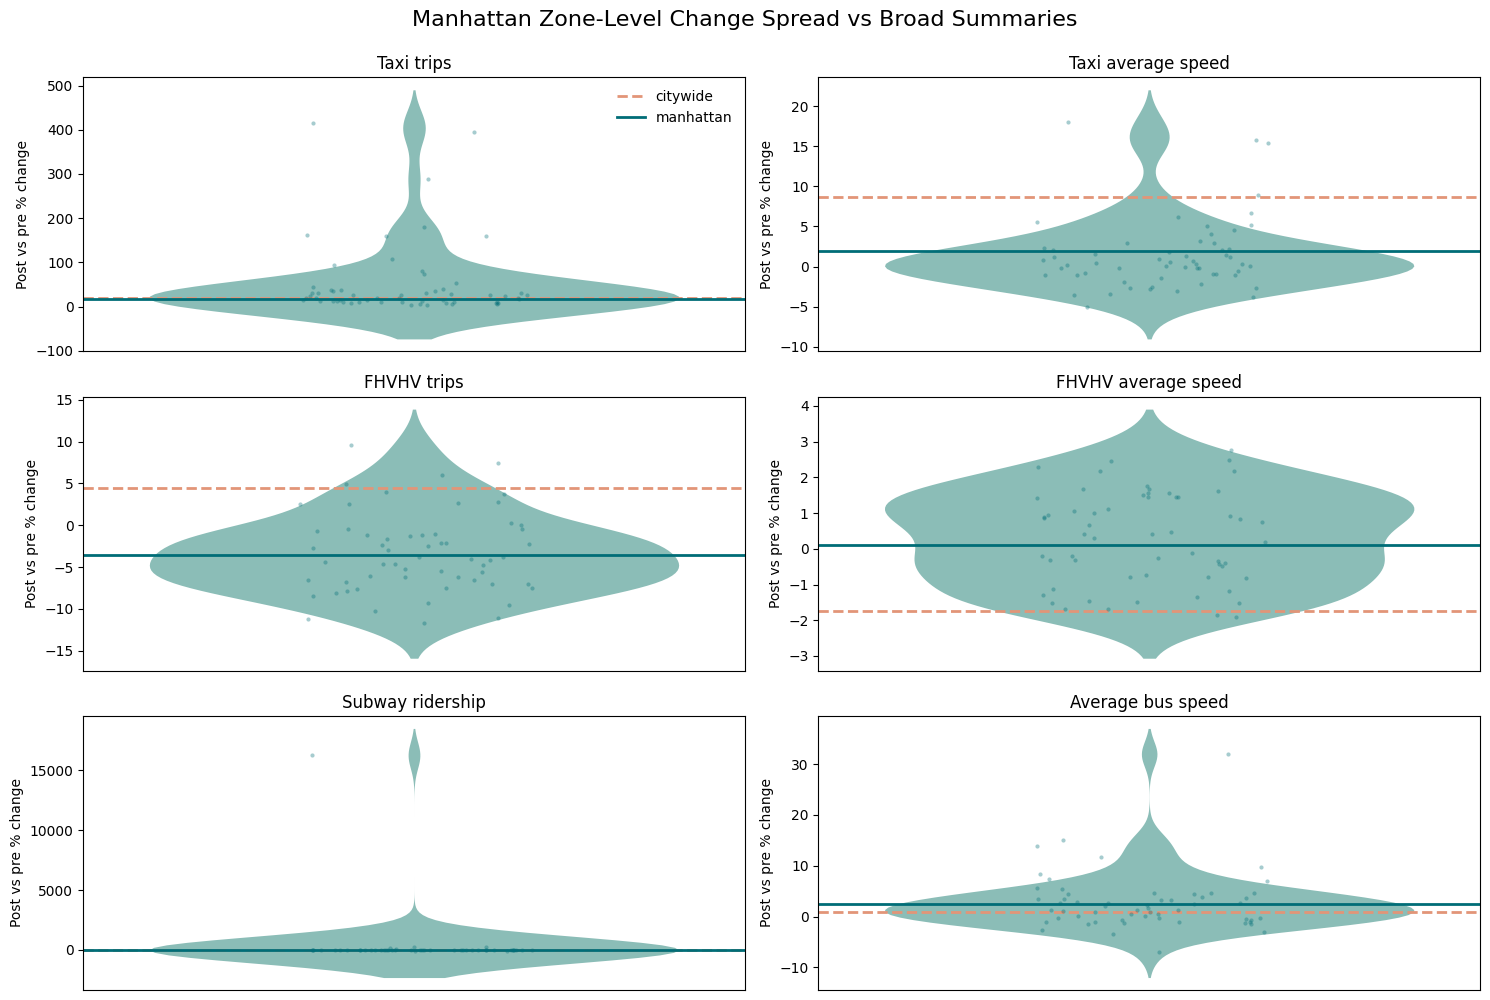

In [36]:
# ---------------------------------------------------------------------
# Visualize Manhattan zone-level change spread against broad summaries
# ---------------------------------------------------------------------

manhattan_zone_change_plot_df = (
    manhattan_zone_change_df.copy()
    .assign(metric_label=lambda df: df["metric"].map(METRIC_LABELS))
)

citywide_change_lookup = aggregation_loss_summary_df.set_index("metric_label")["citywide_pct_change"].to_dict()
manhattan_change_lookup = aggregation_loss_summary_df.set_index("metric_label")["manhattan_pct_change"].to_dict()

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, metric in zip(axes, CORE_MOBILITY_METRICS):
    metric_label = METRIC_LABELS[metric]
    metric_df = manhattan_zone_change_plot_df.loc[
        manhattan_zone_change_plot_df["metric"] == metric
    ].copy()

    sns.violinplot(
        data=metric_df,
        y="pct_change",
        color=BRAND_COLORS["seafoam"],
        inner=None,
        linewidth=0,
        ax=ax,
    )
    sns.stripplot(
        data=metric_df,
        y="pct_change",
        color=BRAND_COLORS["dark_teal"],
        alpha=0.35,
        size=3,
        jitter=0.18,
        ax=ax,
    )

    ax.axhline(citywide_change_lookup[metric_label], color=BRAND_COLORS["terracotta"], linestyle="--", linewidth=2, label="citywide")
    ax.axhline(manhattan_change_lookup[metric_label], color=BRAND_COLORS["dark_teal"], linestyle="-", linewidth=2, label="manhattan")

    ax.set_title(metric_label, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Post vs pre % change")
    ax.set_xticks([])

axes[0].legend(frameon=False, loc="upper right")

fig.suptitle("Manhattan Zone-Level Change Spread vs Broad Summaries", fontsize=16, y=0.995)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        EDA_OUTPUT_DIR / "manhattan_zone_change_spread.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. This distribution view makes the aggregation problem much easier to see than the summary table alone\. Taxi trips are the clearest case: even though the Manhattan\-wide change looks fairly moderate, the underlying zone\-level distribution is extremely wide, with most zones clustered much lower and a long upper tail of neighborhoods that gained far more than the borough summary suggests\. Taxi average speed shows a similar, though less dramatic, pattern: the citywide line sits well above the bulk of Manhattan zones, which means the broader average is overstating how much of Manhattan actually experienced that improvement\. FHVHV trips are more tightly concentrated and mostly negative across Manhattan, so there the borough summary is directionally representative even if some spread remains\. FHVHV average speed is relatively compact as well, with modest local variation around a near\-flat Manhattan change\. Subway ridership is the most extreme example of all, with an enormous positive tail that shows a few Manhattan zones changed vastly more than the rest, while average bus speed also has a visibly asymmetric upside tail\. Overall, the figure makes the core point very clearly: broad citywide or Manhattan averages can be directionally useful, but they often conceal just how uneven the zone\-level response really was\.

### Review unusual periods through a zone\-level lens

Finally, let’s connect a few citywide unusual days back to the selected zones\. The point is not to turn this into a full anomaly notebook, just to see whether those citywide spikes and drops were broad\-based or whether a few selected zones help explain the signal\.

In [37]:
# ---------------------------------------------------------------------
# Review unusual periods through a selected-zone lens
# ---------------------------------------------------------------------

top_unusual_dates_df = (
    citywide_unusual_periods_df.assign(
        abs_standardized_deviation=lambda df: df["standardized_deviation"].abs()
    )
    .sort_values(["metric_label", "abs_standardized_deviation"], ascending=[True, False])
    .groupby("metric", observed=True)
    .head(1)
    .copy()
)

selected_zone_unusual_df = (
    mobility_panel_df.loc[
        mobility_panel_df["taxi_zone_id"].isin(selected_zones_df["taxi_zone_id"])
    ]
    .merge(
        top_unusual_dates_df[["metric", "metric_label", "date", "standardized_deviation"]]
        .rename(columns={"date": "unusual_date", "standardized_deviation": "citywide_standardized_deviation"}),
        how="cross",
    )
)

selected_zone_unusual_df = selected_zone_unusual_df.loc[
    selected_zone_unusual_df["date"] == selected_zone_unusual_df["unusual_date"]
].copy()

unusual_zone_records = []

for _, row in top_unusual_dates_df.iterrows():
    metric = row["metric"]
    unusual_date = row["date"]

    zone_day_df = mobility_panel_df.loc[
        mobility_panel_df["date"] == unusual_date,
        ["taxi_zone_id", "zone", "borough", metric],
    ].copy()

    zone_day_df["zone_rank"] = zone_day_df[metric].rank(ascending=False, method="min")

    selected_day_df = zone_day_df.merge(
        selected_zones_df[["taxi_zone_id", "selection_reason"]],
        on="taxi_zone_id",
        how="inner",
    )

    top_selected_row = selected_day_df.sort_values(metric, ascending=False).iloc[0]

    unusual_zone_records.append(
        {
            "metric_label": METRIC_LABELS[metric],
            "unusual_date": unusual_date,
            "citywide_standardized_deviation": row["standardized_deviation"],
            "top_selected_zone": top_selected_row["zone"],
            "top_selected_zone_borough": top_selected_row["borough"],
            "top_selected_zone_rank": top_selected_row["zone_rank"],
            "top_selected_zone_value": top_selected_row[metric],
        }
    )

selected_zone_unusual_summary_df = pd.DataFrame(unusual_zone_records).round(3)

display(selected_zone_unusual_summary_df)

,metric_label,unusual_date,citywide_standardized_deviation,top_selected_zone,top_selected_zone_borough,top_selected_zone_rank,top_selected_zone_value
0,Average bus speed,2024-01-07,3.304,Arden Heights,Staten Island,13.0,20.342
1,FHVHV average speed,2023-12-25,3.738,Arden Heights,Staten Island,20.0,31.997
2,FHVHV trips,2026-02-23,-3.899,Crown Heights North,Brooklyn,2.0,870.000
3,Subway ridership,2026-03-30,-3.392,Crown Heights North,Brooklyn,11.0,6554.000
4,Taxi average speed,2023-09-04,3.769,East Elmhurst,Queens,49.0,26.827
5,Taxi trips,2023-09-22,-4.513,Upper East Side South,Manhattan,27.0,40.000


Findings\. This table suggests that citywide unusual days do not always come from the same kinds of local zone behavior\. Some broad outliers still show up strongly in selected zones, especially the large negative FHVHV trip and Subway ridership days where Crown Heights North ranks near the top of the zone distribution, which makes those citywide drops feel locally meaningful rather than purely diffuse\. Other unusual days look much less concentrated in the selected set\. For example, the high Taxi speed day and the negative Taxi trip day do not place the selected zones anywhere near the very top of the citywide ranking, which implies that those citywide anomalies were being driven elsewhere or were spread more broadly across many zones\. Arden Heights stands out on the positive bus\-speed and FHVHV\-speed days, but again not always as the single most extreme zone in the city\. So the main takeaway is that some unusual citywide periods do have clear local anchors, while others are more distributed and cannot be explained by just a few handpicked zones\.

## Close

> Clustering Insights\. The temporal and spatial EDA shows that Taxi Zones differ in both overall mobility level and the shape of activity across the ten temporal buckets\. Citywide and borough\-level summaries often hide substantial local variation, and pre/post congestion\-pricing changes are not geographically uniform\. This supports a retrospective clustering design in which each Taxi Zone is represented separately for the pre\-CP and post\-CP periods, with features that preserve both typical mobility level and within\-period temporal pattern\.

The downstream clustering strategy should therefore avoid relying only on period averages or only on geography\. The primary representation should be mobility\-driven, using the six trusted core metrics and their temporal profiles, while borough and congestion\-pricing geography remain interpretation and validation fields\. Static spatial and network context can be tested as an augmented representation, but it should not predetermine the learned mobility neighborhoods\.

This notebook gives us a much clearer picture of which mobility patterns are stable, which ones shifted after congestion pricing, and where those shifts are concentrated in time and space\. Just as importantly, it shows that the most interesting structure often lives below the citywide or borough summary level, which is exactly why the app should let a user move fluidly between broad system views and more local Taxi Zone comparisons\. In that sense, the notebook is not just an EDA artifact; it is also a practical springboard for the app, because many of the strongest temporal, spatial, and policy\-geography contrasts we surfaced here can be translated directly into interactive views, filters, and comparison workflows\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5c43663c-345d-4c21-9332-dd4f928af3ba' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>